# **Parcial elaborado por:**  

Nombre: Juan david parra sierra

ID:     000475676


# **Ámbito del problema: Hábitos de Actividad Física Saludable**

**Archivo disponible:** `patrones_actividad_saludable.csv`  

- **Total de atributos:** 5  
- **Variable dependiente:** 1  
- **Cantidad de registros:** 500  

## **Detalle de los atributos**  

1. **Cantidad de pasos diarios**  
   - Refleja el nivel de movimiento y actividad cotidiana.  

2. **Horas de descanso nocturno**  
   - Representa el ciclo de sueño y recuperación.  

3. **Duración de ejercicio planificado (minutos)**  
   - Corresponde a la práctica de actividad física con intención específica.  

4. **Ritmo cardíaco en reposo**  
   - Mide la condición del sistema cardiovascular.  

5. **Energía consumida (calorías)**  
   - Indica el gasto energético diario total.  


## **Tareas a desarrollar**

1. **Importación y revisión preliminar de los datos**  
2. **Análisis exploratorio (EDA)**  
3. **Preparación y limpieza del dataset**  
4. **Construcción y entrenamiento de los modelos**  
5. **Medición y análisis de resultados**  


#**Importación de Librerias**

In [11]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import scipy as sc
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

print("¡Librerías para Clustering y Análisis de Datos importadas!")
print("Versiones de las principales librerías:")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Sklearn: {sk.__version__}")
print(f"Matplotlib: {mpl.__version__}")
print(f"Scipy: {sc.__version__}")

¡Librerías para Clustering y Análisis de Datos importadas!
Versiones de las principales librerías:
Pandas: 2.2.2
NumPy: 2.0.2
Seaborn: 0.13.2
Sklearn: 1.6.1
Matplotlib: 3.10.0
Scipy: 1.16.2


##1) Carga y exploracion

In [16]:
print("EXPLORACIÓN INICIAL DEL DATASET")
print("="*50)

# Cargar el dataset
try:
    df = pd.read_csv('/content/patrones_actividad_saludable.csv')
    print("\nDataset cargado exitosamente")
    print(f"Dimensiones del dataset: {df.shape}")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

    # Mostrar primeras filas
    print("\nPrimeras 5 filas:")
    display(df.head())

    print("\nInformación del dataset:")
    df.info()

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\n\nESTADÍSTICAS DESCRIPTIVAS")
    print("="*50)

    # Estadísticas de variables numéricas
    print("Variables numéricas:")
    display(df.describe())

    print("\nNúmero de valores únicos por columna:")
    print(df.nunique())

    print("\n\nANÁLISIS DE VALORES FALTANTES")
    print("="*50)

    missing_values = df.isnull().sum()
    print("Valores faltantes por columna:")
    print(missing_values)

except FileNotFoundError:
    print("Error: El archivo 'patrones_actividad_saludable.csv' no se encontró. Asegúrate de que esté en la ubicación correcta.")
except Exception as e:
    print(f"Ocurrió un error al cargar o explorar el dataset: {e}")

EXPLORACIÓN INICIAL DEL DATASET

Dataset cargado exitosamente
Dimensiones del dataset: (500, 6)
Filas: 500, Columnas: 6

Primeras 5 filas:


,pasos_diarios,horas_sueño,minutos_ejercicio,frecuencia_cardiaca_reposo,calorias_quemadas,perfil_real
0,13732,7.8,120,28,4940,Atlético_Elite
1,15910,8.3,120,28,5172,Atlético_Elite
2,11551,6.9,50,55,3173,Muy_Activo
3,9438,7.2,90,41,3172,Atlético
4,4737,8.9,16,68,1910,Ligeramente_Activo



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pasos_diarios               500 non-null    int64  
 1   horas_sueño                 500 non-null    float64
 2   minutos_ejercicio           500 non-null    int64  
 3   frecuencia_cardiaca_reposo  500 non-null    int64  
 4   calorias_quemadas           500 non-null    int64  
 5   perfil_real                 500 non-null    object 
dtypes: float64(1), int64(4), object(1)
memory usage: 23.6+ KB

Tipos de datos:
pasos_diarios                   int64
horas_sueño                   float64
minutos_ejercicio               int64
frecuencia_cardiaca_reposo      int64
calorias_quemadas               int64
perfil_real                    object
dtype: object


ESTADÍSTICAS DESCRIPTIVAS
Variables numéricas:


,pasos_diarios,horas_sueño,minutos_ejercicio,frecuencia_cardiaca_reposo,calorias_quemadas
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,8185.444000,7.558400,51.140000,54.746000,2902.848000
std,5034.115187,0.904691,42.560536,16.158083,1099.583153
min,1000.000000,5.000000,0.000000,27.000000,1087.000000
25%,3792.000000,6.900000,10.000000,41.000000,1942.250000
50%,7836.500000,7.600000,50.000000,55.000000,2799.500000
75%,11750.250000,8.200000,90.000000,69.000000,3754.000000
max,22290.000000,10.000000,149.000000,75.000000,5882.000000



Número de valores únicos por columna:
pasos_diarios                 479
horas_sueño                    45
minutos_ejercicio              44
frecuencia_cardiaca_reposo     16
calorias_quemadas             458
perfil_real                     6
dtype: int64


ANÁLISIS DE VALORES FALTANTES
Valores faltantes por columna:
pasos_diarios                 0
horas_sueño                   0
minutos_ejercicio             0
frecuencia_cardiaca_reposo    0
calorias_quemadas             0
perfil_real                   0
dtype: int64


##2) Analisis exploratorio (EDA)



ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Distribución de las características numéricas:


/tmp/ipython-input-623373696.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette=palette) # Histograma con curva de densidad y paleta


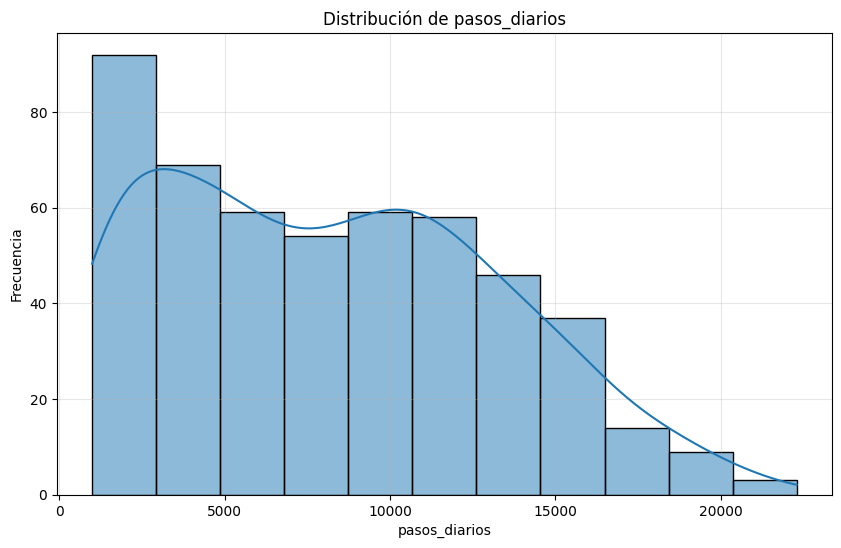

/tmp/ipython-input-623373696.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette=palette) # Histograma con curva de densidad y paleta


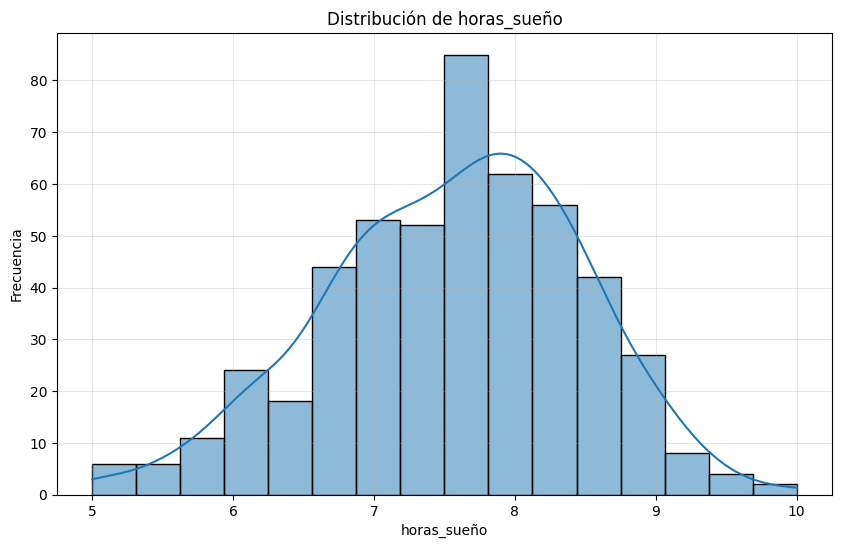

/tmp/ipython-input-623373696.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette=palette) # Histograma con curva de densidad y paleta


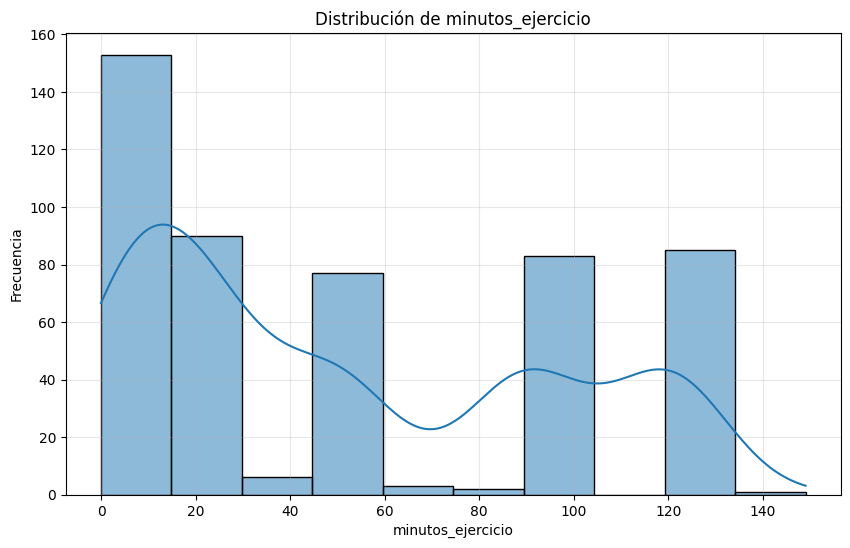

/tmp/ipython-input-623373696.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette=palette) # Histograma con curva de densidad y paleta


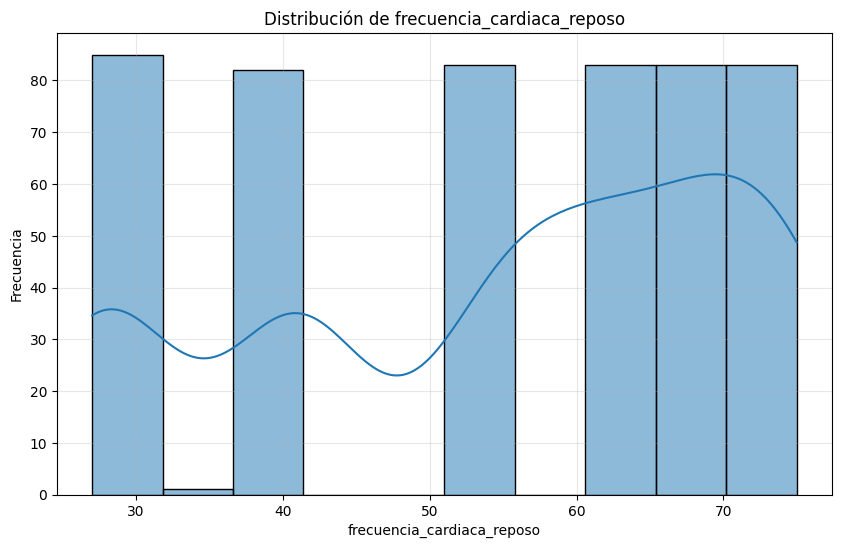

/tmp/ipython-input-623373696.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette=palette) # Histograma con curva de densidad y paleta


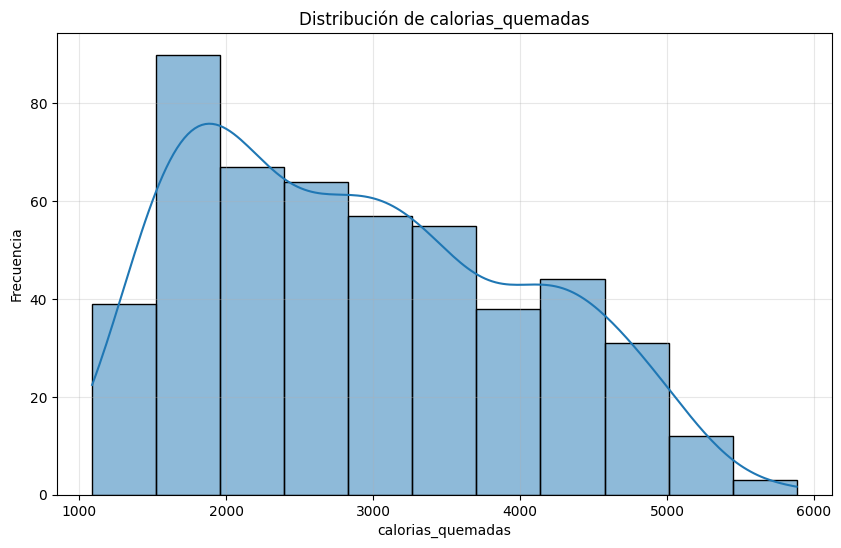



MATRIZ DE CORRELACIÓN


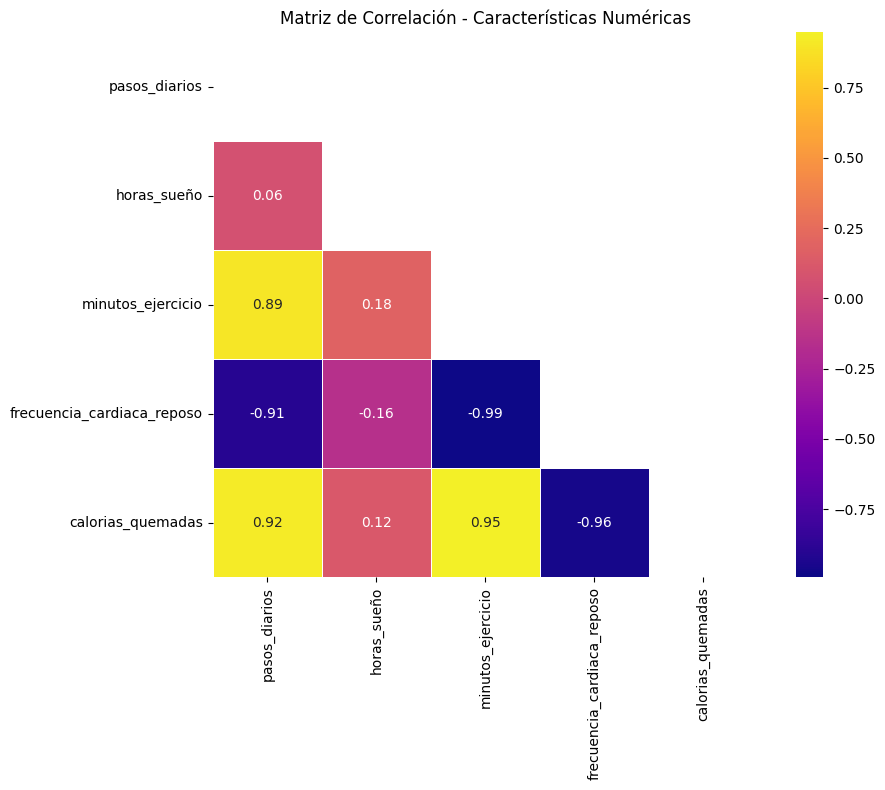



RELACIONES ENTRE PARES DE VARIABLES NUMÉRICAS


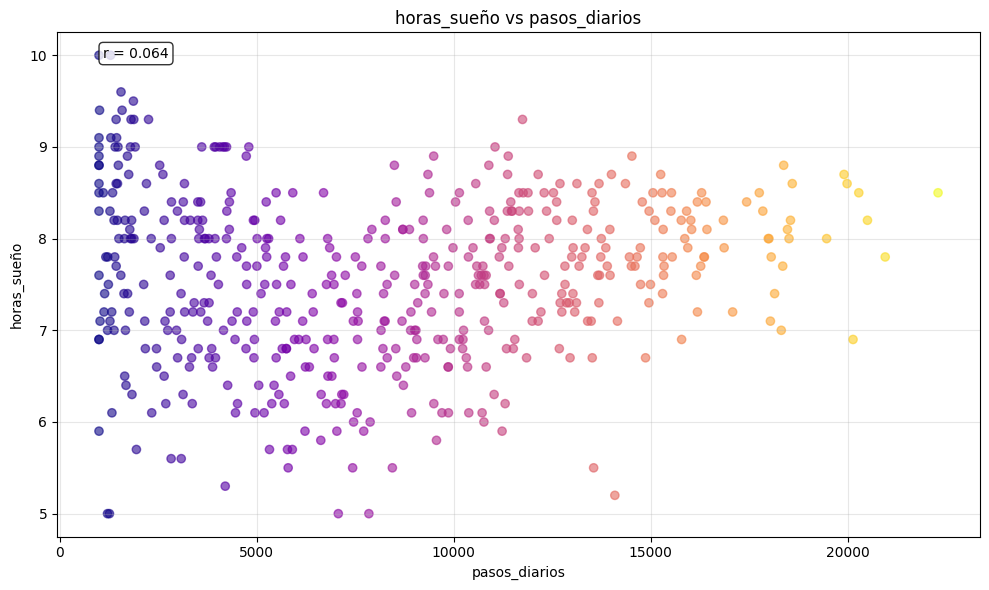

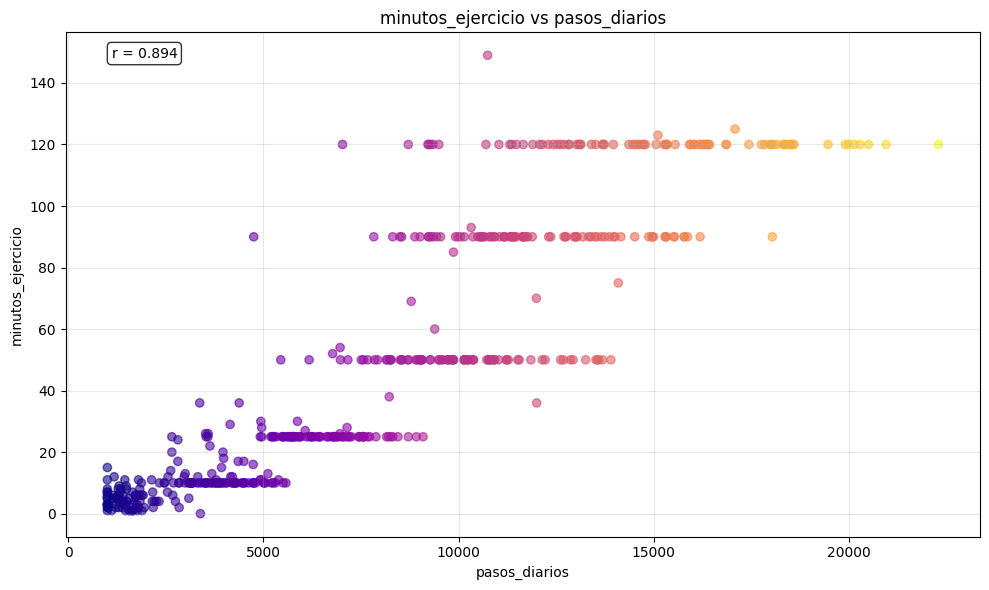

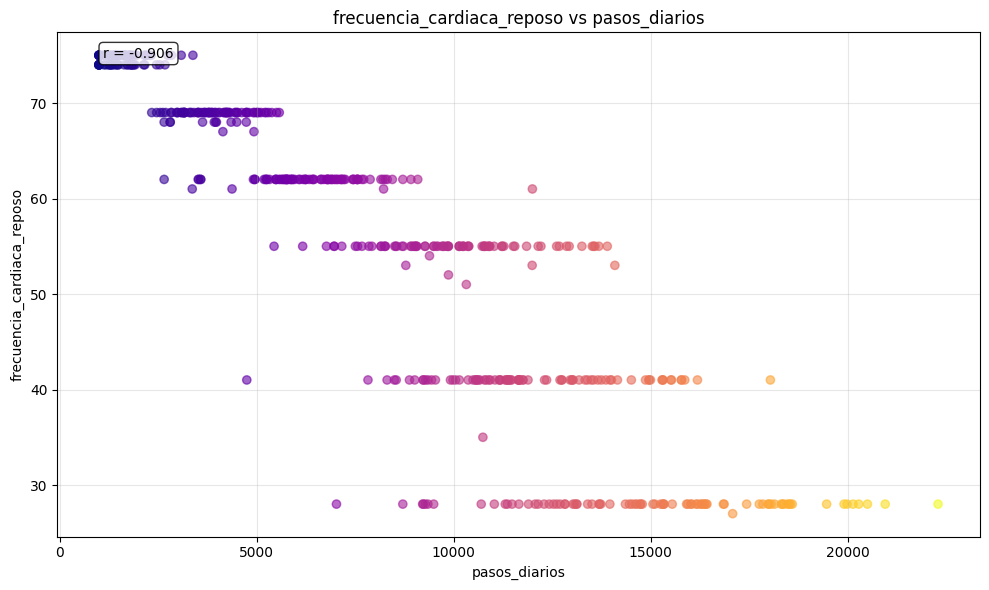

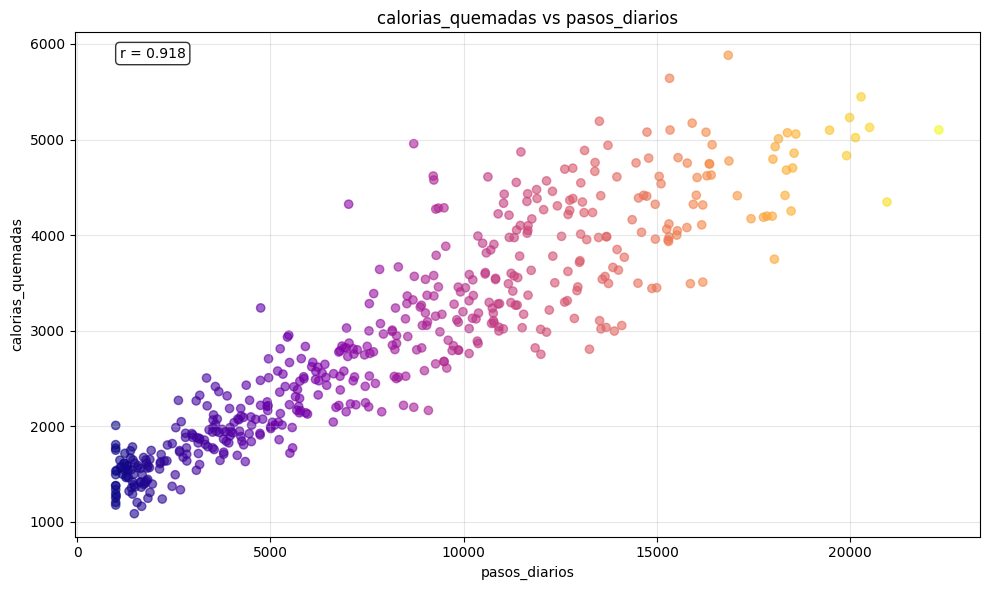

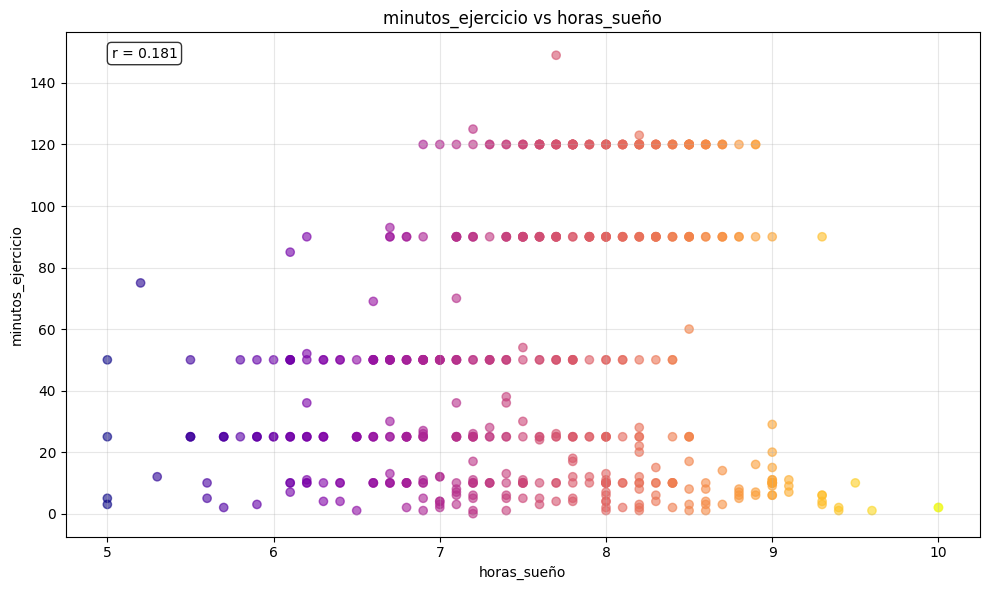

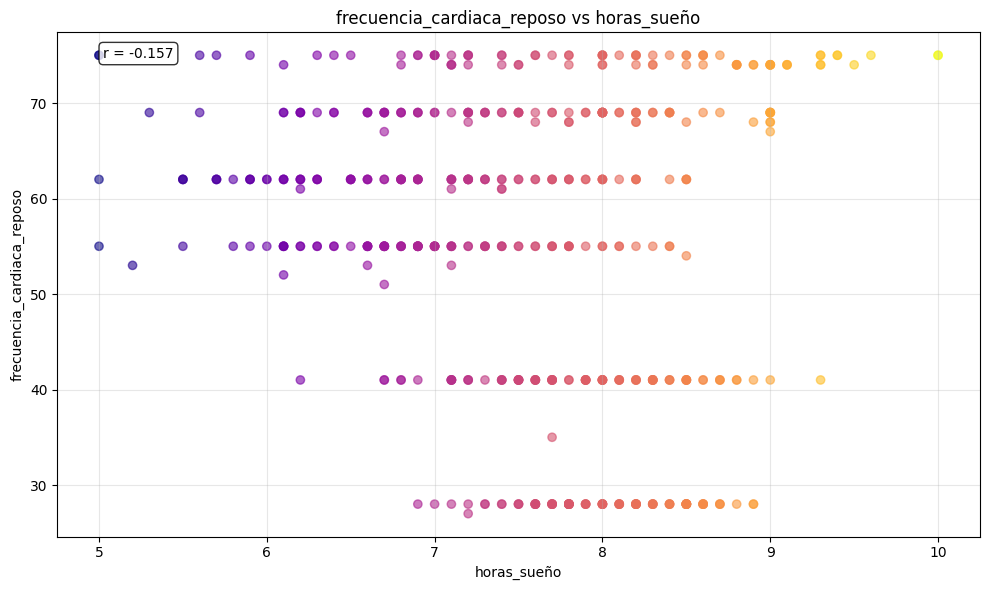

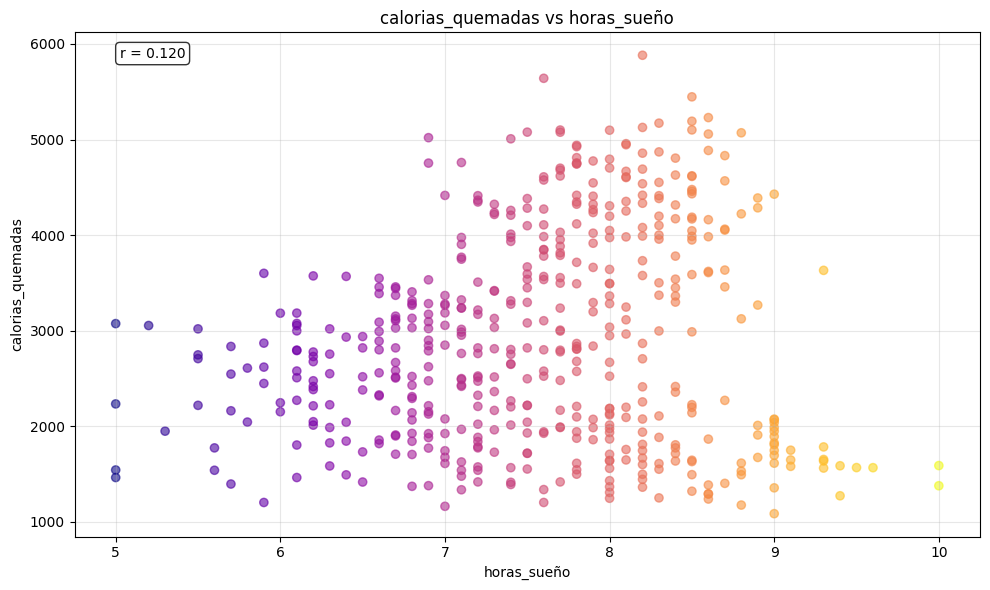

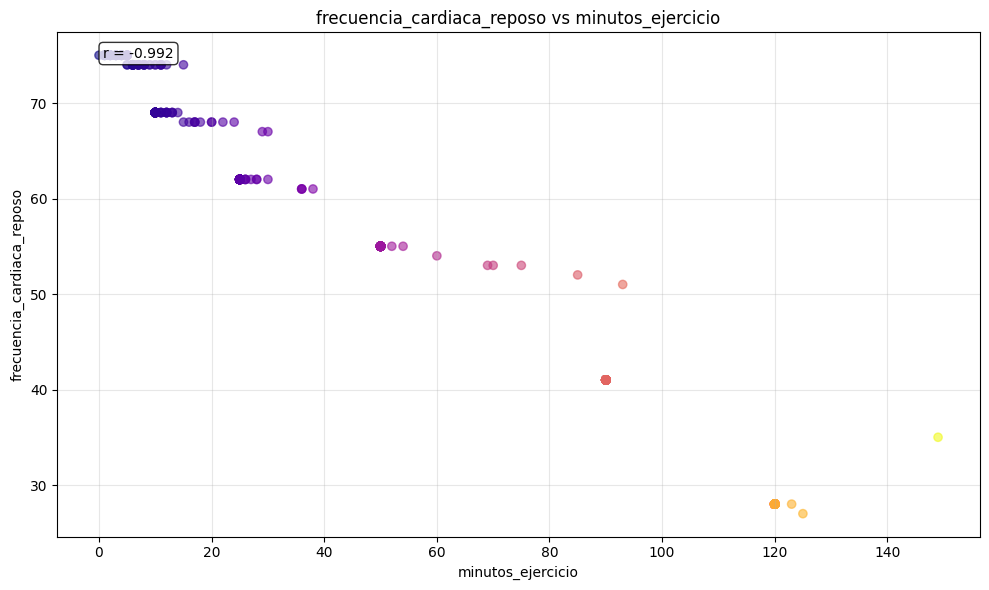

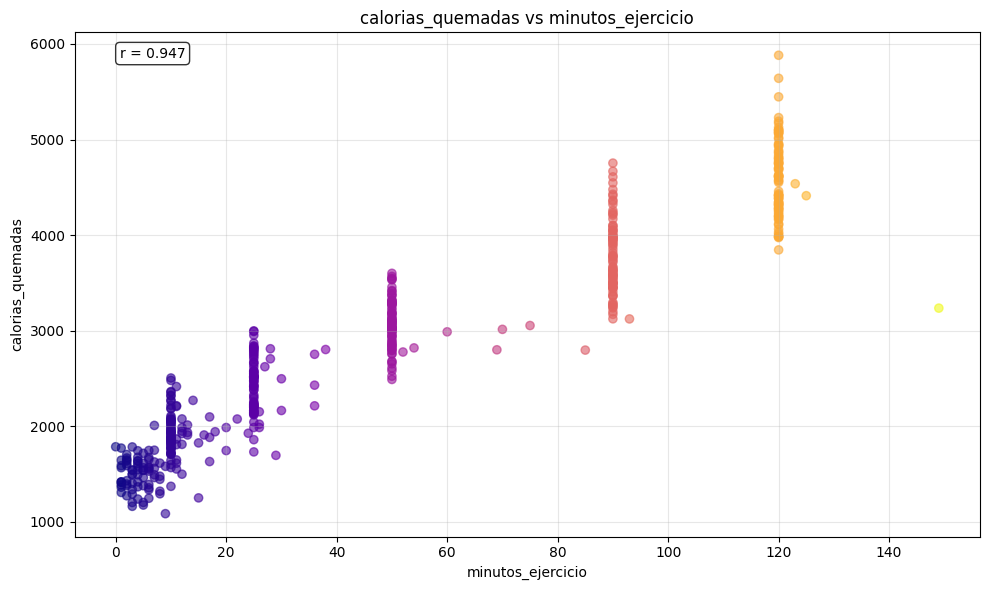

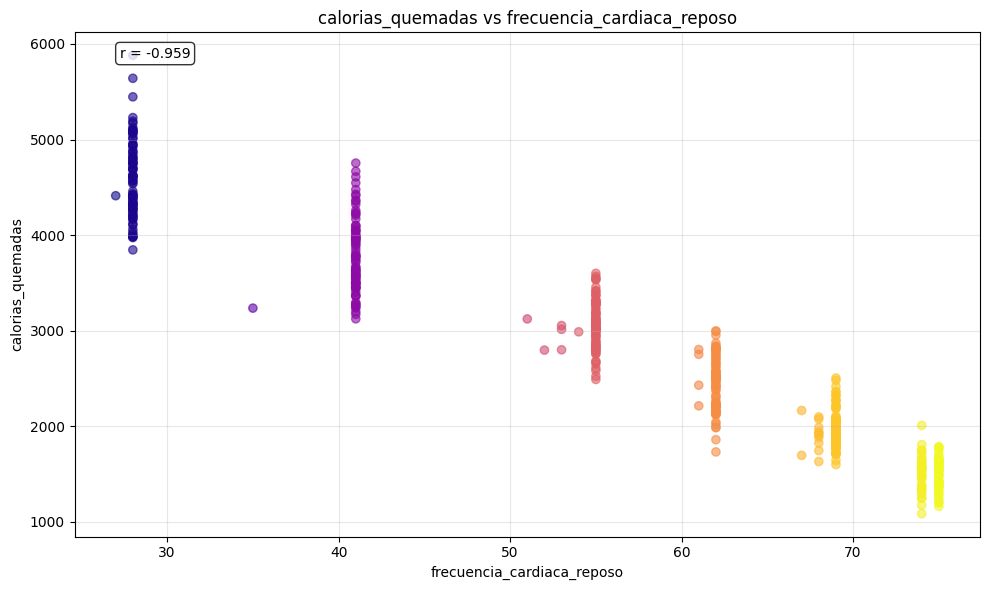


ANÁLISIS DE LA VARIABLE CATEGÓRICA: perfil_real

Distribución de perfil_real:
perfil_real
Atlético_Elite          85
Muy_Activo              83
Atlético                83
Ligeramente_Activo      83
Moderadamente_Activo    83
Sedentario              83
Name: count, dtype: int64


/tmp/ipython-input-623373696.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='perfil_real', order=df['perfil_real'].value_counts().index, palette=palette) # Countplot de la variable categórica


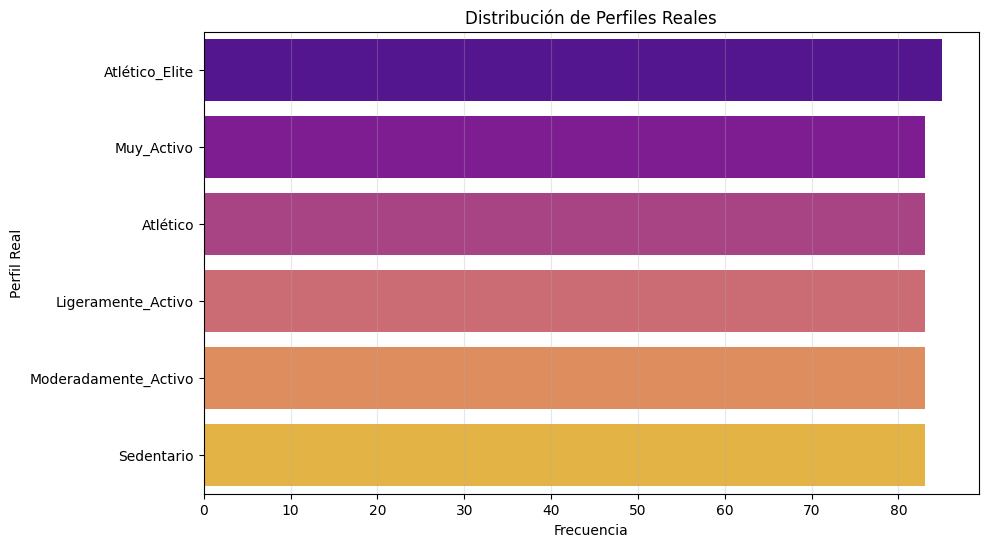


Boxplots de características numéricas por perfil_real:


/tmp/ipython-input-623373696.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='perfil_real', y=feature, palette=palette) # Boxplot para visualizar la distribución de features por cada perfil real


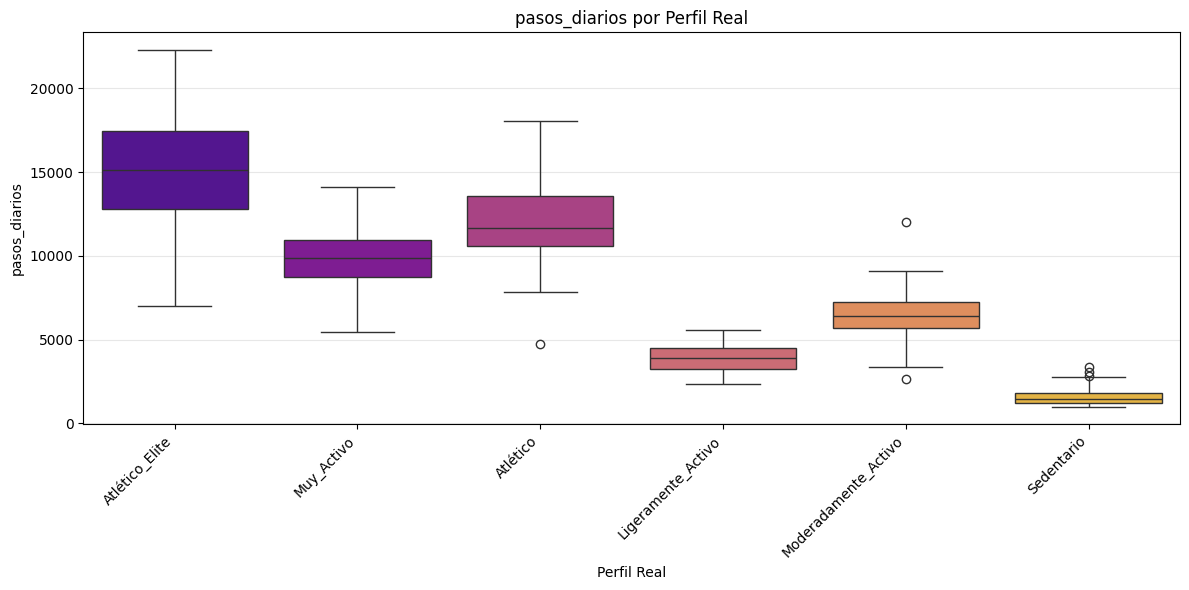

/tmp/ipython-input-623373696.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='perfil_real', y=feature, palette=palette) # Boxplot para visualizar la distribución de features por cada perfil real


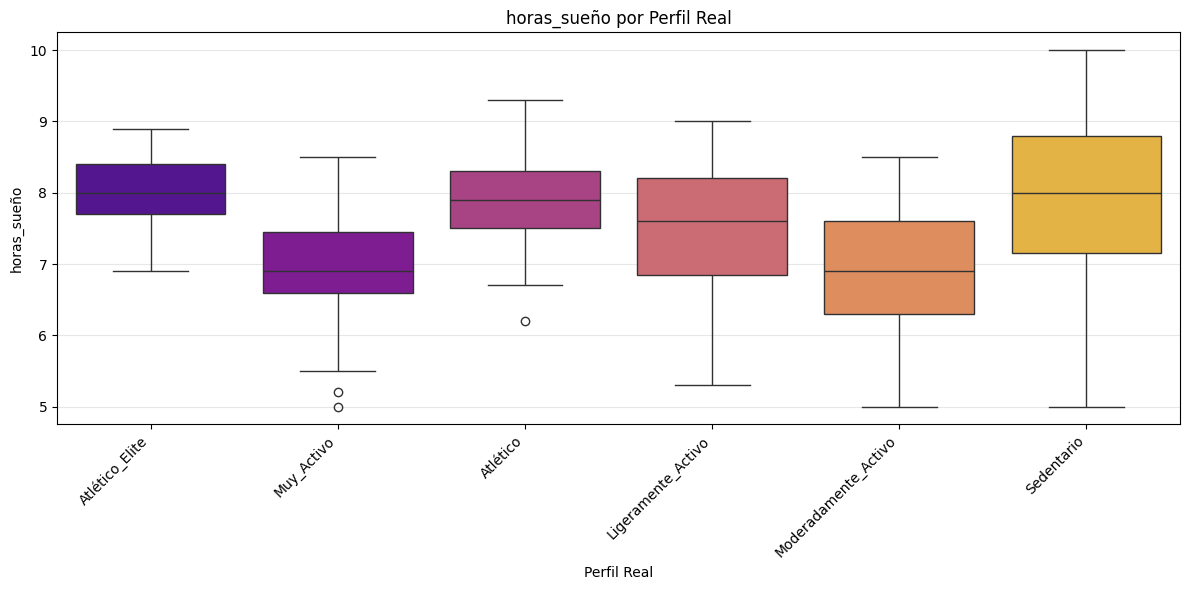

/tmp/ipython-input-623373696.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='perfil_real', y=feature, palette=palette) # Boxplot para visualizar la distribución de features por cada perfil real


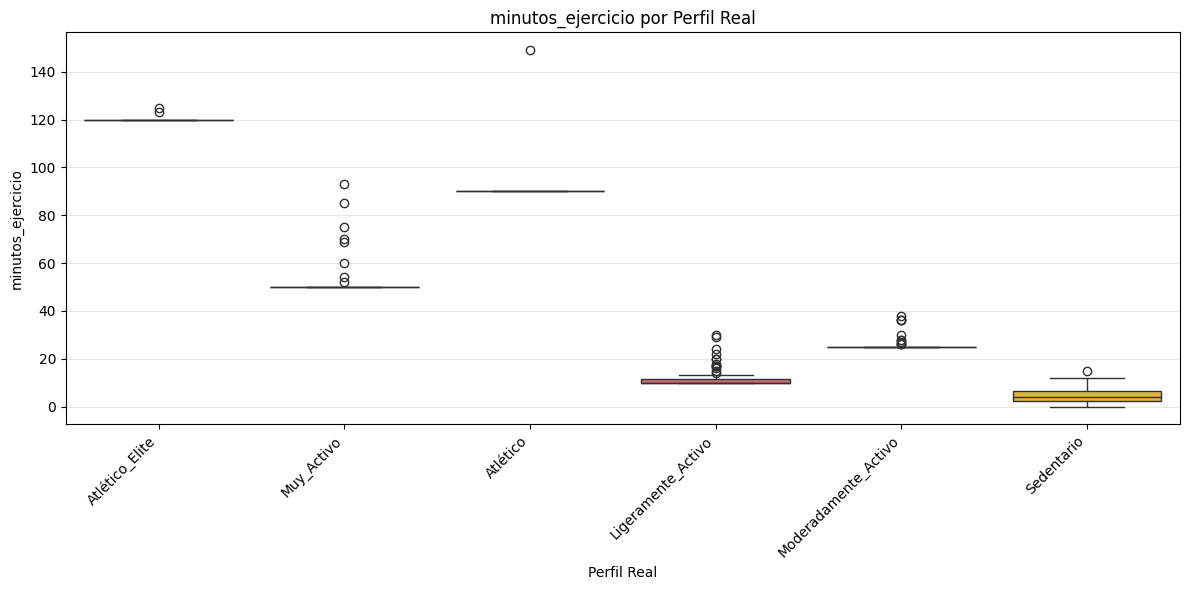

/tmp/ipython-input-623373696.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='perfil_real', y=feature, palette=palette) # Boxplot para visualizar la distribución de features por cada perfil real


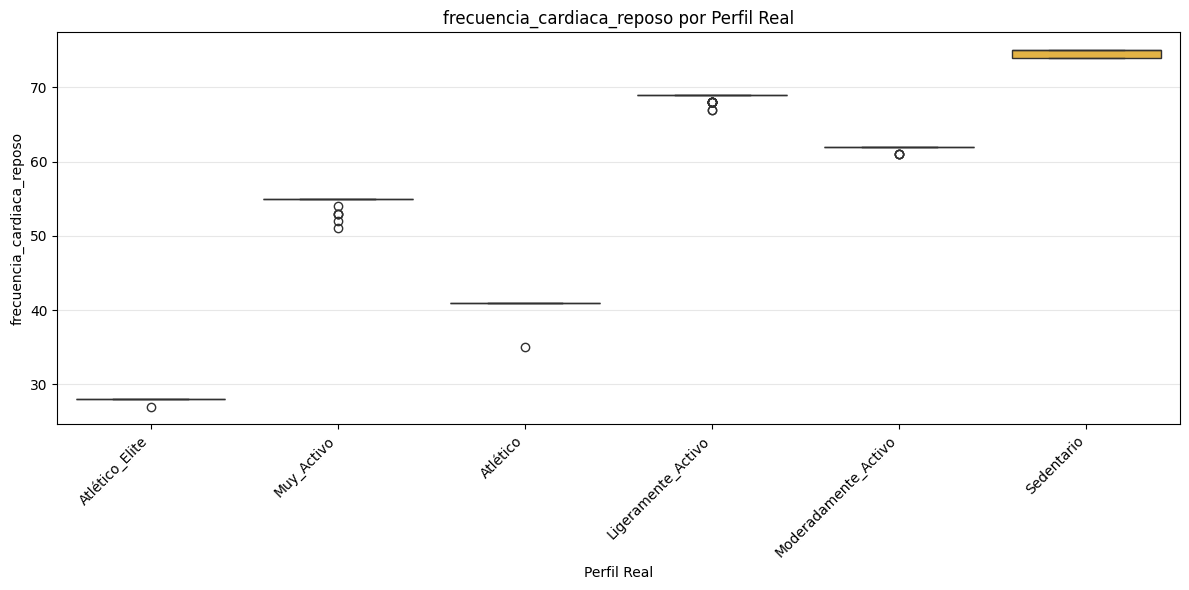

/tmp/ipython-input-623373696.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='perfil_real', y=feature, palette=palette) # Boxplot para visualizar la distribución de features por cada perfil real


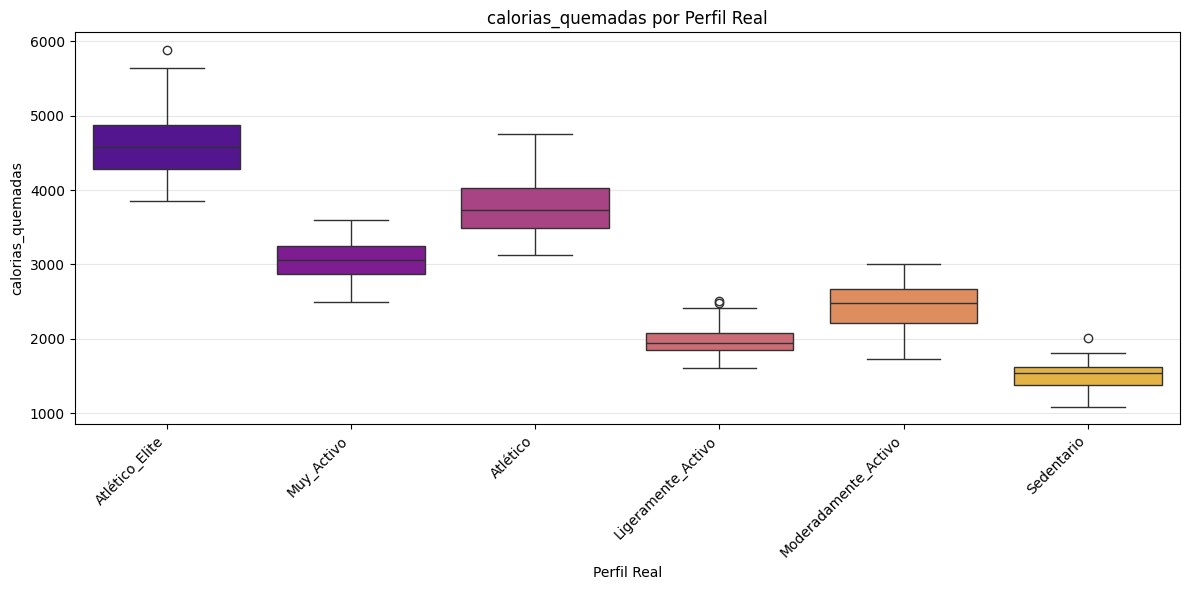



PAIRPLOT DE VARIABLES NUMÉRICAS POR PERFIL REAL


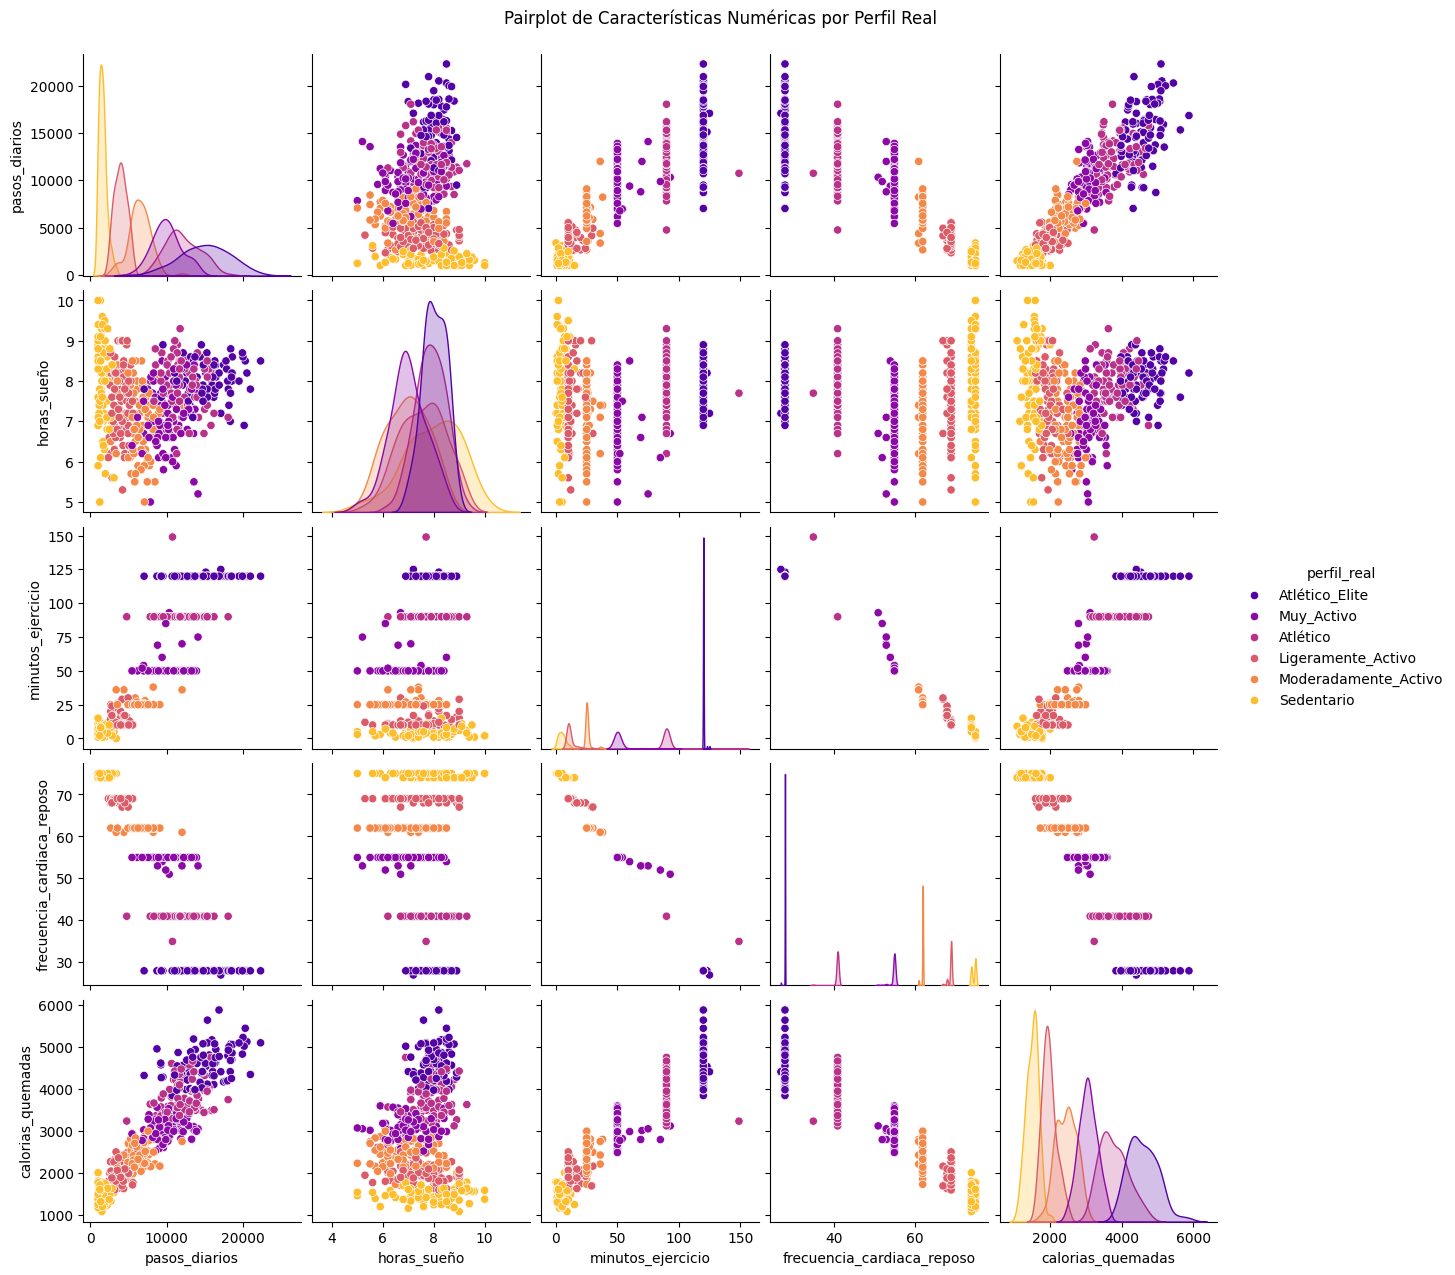

In [17]:
# Realiza el Análisis Exploratorio de Datos (EDA)
print("\n\nANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*50)

# Analizar la distribución de cada característica para comprender los patrones de datos.

# Seleccionar columnas numéricas (excluyendo 'perfil_real' que es la etiqueta conocida)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Definir la paleta de colores
palette = 'plasma'

# 1. Distribución de las características numéricas
print("\nDistribución de las características numéricas:")

for feature in numeric_features:
    plt.figure(figsize=(10, 6)) # Crear una figura para cada gráfico
    sns.histplot(df[feature], kde=True, palette=palette) # Histograma con curva de densidad y paleta
    plt.title(f'Distribución de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)
    plt.show()

# 2. Matriz de correlación de variables numéricas
print("\n\nMATRIZ DE CORRELACIÓN")
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8)) # Crear una figura para la matriz de correlación
# Crear una máscara para mostrar solo la mitad inferior de la matriz (evitar duplicidad)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True, # Mostrar los valores de correlación
            cmap=palette, # Aplicar la paleta de colores
            center=0, # Centrar el mapa de colores en 0
            square=True, # Asegurar celdas cuadradas
            fmt='.2f', # Formato de los números con 2 decimales
            linewidths=.5) # Ancho de las líneas entre celdas
plt.title('Matriz de Correlación - Características Numéricas')
plt.tight_layout()
plt.show()

# 3. Relaciones entre pares de variables numéricas (Scatter plots)
print("\n\nRELACIONES ENTRE PARES DE VARIABLES NUMÉRICAS")

# Generar combinaciones únicas de pares de características numéricas para scatter plots
feature_combinations = [(numeric_features[i], numeric_features[j])
                        for i in range(len(numeric_features))
                        for j in range(i + 1, len(numeric_features))]

for feature1, feature2 in feature_combinations:
    plt.figure(figsize=(10, 6)) # Crear una figura para cada scatter plot
    plt.scatter(df[feature1], df[feature2], alpha=0.6, c=df[feature1], cmap=palette) # Scatter plot con transparencia y coloreado por feature1
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f'{feature2} vs {feature1}')
    plt.grid(True, alpha=0.3)

    # Calcular y mostrar la correlación entre las dos variables
    corr = df[feature1].corr(df[feature2])
    plt.text(0.05, 0.95, f'r = {corr:.3f}',
                         transform=plt.gca().transAxes, # Posicionar texto relativo a los ejes actuales
                         fontsize=10,
                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

# 4. Análisis de la variable 'perfil_real' (categórica)
print(f"\nANÁLISIS DE LA VARIABLE CATEGÓRICA: perfil_real")

# Mostrar la distribución de los perfiles reales
print("\nDistribución de perfil_real:")
print(df['perfil_real'].value_counts())

plt.figure(figsize=(10, 6)) # Crear una figura para el countplot
sns.countplot(data=df, y='perfil_real', order=df['perfil_real'].value_counts().index, palette=palette) # Countplot de la variable categórica
plt.title('Distribución de Perfiles Reales')
plt.xlabel('Frecuencia')
plt.ylabel('Perfil Real')
plt.grid(axis='x', alpha=0.3)
plt.show()

# 5. Boxplots de características numéricas por 'perfil_real'
print("\nBoxplots de características numéricas por perfil_real:")

for feature in numeric_features:
    plt.figure(figsize=(12, 6)) # Crear una figura para cada boxplot
    sns.boxplot(data=df, x='perfil_real', y=feature, palette=palette) # Boxplot para visualizar la distribución de features por cada perfil real
    plt.title(f'{feature} por Perfil Real')
    plt.xlabel('Perfil Real')
    plt.ylabel(feature)
    plt.xticks(rotation=45, ha='right') # Rotar etiquetas del eje X para mejor legibilidad
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6. Pairplot para visualizar relaciones entre pares de variables numéricas coloreado por 'perfil_real'
# Esta visualización ayuda a identificar si los perfiles reales forman agrupaciones visualmente distintas en el espacio de características.
print("\n\nPAIRPLOT DE VARIABLES NUMÉRICAS POR PERFIL REAL")
sns.pairplot(df, hue='perfil_real', diag_kind='kde', palette=palette) # Pairplot con curvas de densidad en la diagonal y coloreado por perfil real
plt.suptitle('Pairplot de Características Numéricas por Perfil Real', y=1.02) # Título general para el pairplot
plt.show()

# Los scatter plots individuales de relaciones entre pares se mantienen ya que proporcionan la correlación calculada,
# lo cual complementa la visualización del pairplot.

##3) Preprocesamiento de datos

In [18]:
# Preprocesamiento de datos

print("\n\nPREPROCESAMIENTO DE DATOS")
print("="*50)

# Crear una copia del dataset original
df_processed = df.copy()
print("Copia del dataset creada para preprocesamiento.")

# Manejo de valores faltantes (verificado en EDA)
print("\nVerificando valores faltantes...")
missing_before = df_processed.isnull().sum().sum()
print(f"Valores faltantes antes: {missing_before}")
# No se encontraron valores faltantes en el EDA, por lo que no se requiere eliminación.
print("No se encontraron valores faltantes. No se requiere eliminar filas.")
print()

# Selección de características numéricas para clustering
# Excluir 'perfil_real'
features_for_clustering = df_processed.select_dtypes(include=[np.number]).columns.tolist()

print(f"Características numéricas seleccionadas para clustering: {features_for_clustering}")
print()

# Separar las características
X = df_processed[features_for_clustering]

# Escalado de características numéricas
# Estandarización es crucial para algoritmos basados en distancia
print("Escalando características numéricas...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Características numéricas escaladas.")
print(f"Forma del dataset escalado: {X_scaled.shape}")

# Convertir a DataFrame para facilitar la visualización (opcional)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
print("\nPrimeras 5 filas del dataset escalado:")
display(X_scaled_df.head())

print("\nPreprocesamiento completado.")

# Guardar las etiquetas reales para evaluación posterior
y_true = df_processed['perfil_real']
print("\nEtiquetas reales ('perfil_real') guardadas para evaluación.")

# Resumen del preprocesamiento para Clustering
print("\n\n=== RESUMEN DEL PREPROCESAMIENTO ===")
print(f"Dataset original: {df.shape}")
print(f"Dataset para clustering (escalado): {X_scaled.shape}")
print(f"Características numéricas seleccionadas y escaladas: {len(features_for_clustering)}")
print("Manejo de valores faltantes verificado (no se encontraron)")
print("Etiquetas reales ('perfil_real') separadas para evaluación")
print("\n¡Datos listos para los algoritmos de clustering!")



PREPROCESAMIENTO DE DATOS
Copia del dataset creada para preprocesamiento.

Verificando valores faltantes...
Valores faltantes antes: 0
No se encontraron valores faltantes. No se requiere eliminar filas.

Características numéricas seleccionadas para clustering: ['pasos_diarios', 'horas_sueño', 'minutos_ejercicio', 'frecuencia_cardiaca_reposo', 'calorias_quemadas']

Escalando características numéricas...
Características numéricas escaladas.
Forma del dataset escalado: (500, 5)

Primeras 5 filas del dataset escalado:


,pasos_diarios,horas_sueño,minutos_ejercicio,frecuencia_cardiaca_reposo,calorias_quemadas
0,1.102897,0.267320,1.619551,-1.656928,1.854514
1,1.535978,0.820548,1.619551,-1.656928,2.065714
2,0.669219,-0.728491,-0.026812,0.015735,0.245932
3,0.249063,-0.396554,0.913967,-0.851572,0.245022
4,-0.685701,1.484422,-0.826474,0.821092,-0.903836



Preprocesamiento completado.

Etiquetas reales ('perfil_real') guardadas para evaluación.


=== RESUMEN DEL PREPROCESAMIENTO ===
Dataset original: (500, 6)
Dataset para clustering (escalado): (500, 5)
Características numéricas seleccionadas y escaladas: 5
Manejo de valores faltantes verificado (no se encontraron)
Etiquetas reales ('perfil_real') separadas para evaluación

¡Datos listos para los algoritmos de clustering!


### **Acción No. 4: Implementación y Entrenamiento de Modelos**

In [20]:
# Implementación y Entrenamiento de Modelos

print("\n\nIMPLEMENTACION Y ENTRENAMIENTO DE MODELOS DE CLUSTERING")
print("="*60)

# --- ALGORITMO K-MEANS ---
print("\n\nALGORITMO K-MEANS")
print("=" * 40)

# Implementar K-Means
# Usamos 6 clusters ya que conocemos los 6 perfiles reales.
# n_init=10 es recomendado para evitar problemas con inicializaciones locales.
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Obtener centroides (en escala original para posible visualización, aunque no siempre necesaria para evaluación)
# Los centroides en escala original pueden ser útiles para interpretar el significado de los clusters.
centroids_scaled = kmeans.cluster_centers_
# centroids_original = scaler.inverse_transform(centroids_scaled) # Requiere acceso al scaler si se hizo en otra celda

# Métricas de evaluación para K-Means
print("\nMETRICAS DE EVALUACION (K-Means):")

# Silhouette Score
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score: {kmeans_silhouette:.4f}")

# Davies-Bouldin Index
kmeans_db_score = davies_bouldin_score(X_scaled, kmeans_labels)
print(f"Davies-Bouldin Index: {kmeans_db_score:.4f}")

# Calinski-Harabasz Index
kmeans_ch_score = calinski_harabasz_score(X_scaled, kmeans_labels)
print(f"Calinski-Harabasz Index: {kmeans_ch_score:.4f}")


# Métricas específicas de K-Means
kmeans_wcss = kmeans.inertia_
total_ss = np.sum((X_scaled - np.mean(X_scaled, axis=0))**2)
kmeans_bcss = total_ss - kmeans_wcss

print(f"\nMETRICAS ESPECIFICAS DE K-MEANS:")
print(f"WCSS (Inertia): {kmeans_wcss:.4f}")
print(f"BCSS: {kmeans_bcss:.4f}")
print(f"Varianza explicada por el clustering (BCSS/TSS): {(kmeans_bcss/total_ss):.4f}")
print(f"Iteraciones hasta convergencia: {kmeans.n_iter_}")


# Agregar las etiquetas de cluster K-Means al DataFrame original
df['KMeans_Cluster'] = kmeans_labels

print(f"\nDistribucion de clusters K-Means encontrados:")
print(df['KMeans_Cluster'].value_counts().sort_index())

print("\nK-Means implementado y evaluado.")

# --- ALGORITMO DBSCAN ---
print("\n\nALGORITMO DBSCAN")
print("=" * 40)

# Implementar DBSCAN
# Parámetros eps y min_samples pueden requerir ajuste
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Identificar puntos de ruido (-1)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
noise_percentage = (n_noise / len(dbscan_labels)) * 100

# Métricas de evaluación (solo para puntos no-ruido si hay >1 cluster válido)
print("\nMETRICAS DE EVALUACION (DBSCAN):")

if n_clusters_dbscan >= 2: # Se necesitan al menos 2 clusters para estas métricas
    non_noise_mask = dbscan_labels != -1
    X_no_noise = X_scaled[non_noise_mask]
    labels_no_noise = dbscan_labels[non_noise_mask]

    dbscan_silhouette = silhouette_score(X_no_noise, labels_no_noise)
    dbscan_db_score = davies_bouldin_score(X_no_noise, labels_no_noise)
    dbscan_ch_score = calinski_harabasz_score(X_no_noise, labels_no_noise)

    print(f"Silhouette Score (sin ruido): {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index (sin ruido): {dbscan_db_score:.4f}")
    print(f"Calinski-Harabasz Index (sin ruido): {dbscan_ch_score:.4f}")

elif n_clusters_dbscan == 1: # Si solo se encontró un cluster
     print("Solo se encontro 1 cluster valido. Metricas como Silhouette y Davies-Bouldin no aplican.")
     dbscan_silhouette = np.nan # No aplicable
     dbscan_db_score = np.nan # No aplicable
     dbscan_ch_score = np.nan # No aplicable

else: # No se encontraron clusters válidos
    print("No se encontraron clusters validos. No se pudieron calcular metricas.")
    dbscan_silhouette = np.nan # No aplicable
    dbscan_db_score = np.nan # No aplicable
    dbscan_ch_score = np.nan # No aplicable


print(f"\nRESULTADOS ESPECIFICOS DE DBSCAN:")
print(f"Clusters encontrados (excluyendo ruido): {n_clusters_dbscan}")
print(f"Puntos de ruido identificados (-1): {n_noise} ({noise_percentage:.1f}%)")
print(f"Parametros usados: eps={dbscan.eps}, min_samples={dbscan.min_samples}")


# Agregar las etiquetas DBSCAN al DataFrame original (incluye ruido)
df['DBSCAN_Cluster'] = dbscan_labels

print(f"\nDistribucion de clusters DBSCAN encontrados (incluyendo ruido):")
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"   Ruido (etiqueta -1): {count} puntos")
    else:
        print(f"   Cluster {cluster_id}: {count} puntos")

print("\nDBSCAN implementado y evaluado.")

# --- ALGORITMO HIERARCHICAL CLUSTERING ---
print("\n\nALGORITMO HIERARCHICAL CLUSTERING")
print("=" * 40)

# Implementar Agglomerative Clustering
# Usamos 6 clusters para comparación
hierarchical = AgglomerativeClustering(n_clusters=6, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Métricas de evaluación para Hierarchical Clustering
print("\nMETRICAS DE EVALUACION (Hierarchical Clustering):")

# Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_db_score = davies_bouldin_score(X_scaled, hierarchical_labels)
hierarchical_ch_score = calinski_harabasz_score(X_scaled, hierarchical_labels)

print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hierarchical_db_score:.4f}")
print(f"Calinski-Harabasz Index: {hierarchical_ch_score:.4f}")

# Métrica específica para evaluar la calidad de la estructura jerárquica
print("\nMETRICA ESPECIFICA (Correlacion Cofenetica):")
# Calcular la matriz de enlace y la correlación cofenética
linkage_matrix = linkage(X_scaled, method='ward')
original_distances = pdist(X_scaled)
cophenet_corr, _ = cophenet(linkage_matrix, original_distances)

print(f"Correlacion Cofenetica: {cophenet_corr:.4f}")

# Información sobre la estructura jerárquica
n_clusters_hierarchical = len(set(hierarchical_labels))

print(f"\nRESULTADOS ESPECIFICOS DE HIERARCHICAL CLUSTERING:")
print(f"Clusters formados (para n_clusters={hierarchical.n_clusters}): {n_clusters_hierarchical}")
print(f"Metodo de enlace (Linkage): {hierarchical.linkage}")


# Agregar las etiquetas Hierarchical al DataFrame original
df['Hierarchical_Cluster'] = hierarchical_labels

print(f"\nDistribucion de clusters Hierarchical encontrados:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

print("\nHierarchical Clustering implementado y evaluado.")



IMPLEMENTACION Y ENTRENAMIENTO DE MODELOS DE CLUSTERING


ALGORITMO K-MEANS

METRICAS DE EVALUACION (K-Means):
Silhouette Score: 0.3340
Davies-Bouldin Index: 1.0015
Calinski-Harabasz Index: 603.3561

METRICAS ESPECIFICAS DE K-MEANS:
WCSS (Inertia): 351.7736
BCSS: 2148.2264
Varianza explicada por el clustering (BCSS/TSS): 0.8593
Iteraciones hasta convergencia: 10

Distribucion de clusters K-Means encontrados:
KMeans_Cluster
0     71
1     86
2     56
3     83
4    106
5     98
Name: count, dtype: int64

K-Means implementado y evaluado.


ALGORITMO DBSCAN

METRICAS DE EVALUACION (DBSCAN):
Silhouette Score (sin ruido): 0.3147
Davies-Bouldin Index (sin ruido): 0.9099
Calinski-Harabasz Index (sin ruido): 367.1804

RESULTADOS ESPECIFICOS DE DBSCAN:
Clusters encontrados (excluyendo ruido): 5
Puntos de ruido identificados (-1): 36 (7.2%)
Parametros usados: eps=0.5, min_samples=5

Distribucion de clusters DBSCAN encontrados (incluyendo ruido):
   Ruido (etiqueta -1): 36 puntos
   Cluster 0: 7

### **Visualización comparativa en espacios de menor dimensionalidad**

Con el fin de contrastar los resultados de distintos algoritmos de clustering (K-Means, DBSCAN, Jerárquico) frente a los perfiles reales (*Ground Truth*), se proyectarán los datos de 5 dimensiones a 2D mediante técnicas de reducción de dimensionalidad. Esto facilita interpretar la organización de los clusters.

Se emplearán dos métodos habituales:

1. **PCA (Análisis de Componentes Principales):**  
   - **Definición:** Identifica direcciones que concentran la mayor varianza de los datos y proyecta sobre ellas.  
   - **Utilidad:** Permite observar la estructura global y cómo se concentra la variabilidad.  
   - **Lectura:** Los puntos suelen aparecer **más dispersos**, pues la técnica prioriza distancias globales y varianza. Los ejes reflejan la varianza explicada.  

2. **t-SNE (t-Distributed Stochastic Neighbor Embedding):**  
   - **Definición:** Método no lineal que preserva relaciones locales entre puntos.  
   - **Utilidad:** Resalta estructuras de agrupamiento local y hace más visibles los clusters.  
   - **Lectura:** Los clusters aparecen **más compactos y definidos** que en PCA. Los ejes no tienen interpretación directa ni son comparables con los de PCA.  

Ambas visualizaciones aportan perspectivas complementarias: PCA muestra la visión global de la distribución, mientras t-SNE enfatiza la cercanía local. Comparar cada algoritmo de clustering en estos dos espacios proyectados permite analizar mejor cómo forman los grupos y qué tan consistentes son frente a los perfiles reales.  
**Nota:** Las escalas de los ejes no deben compararse entre PCA y t-SNE; el interés está en la disposición relativa de puntos y clusters en cada gráfico.  


**Visualizacion de resultados con (PCA)**



VISUALIZACION COMPARATIVA DE RESULTADOS EN ESPACIO PCA (2D)


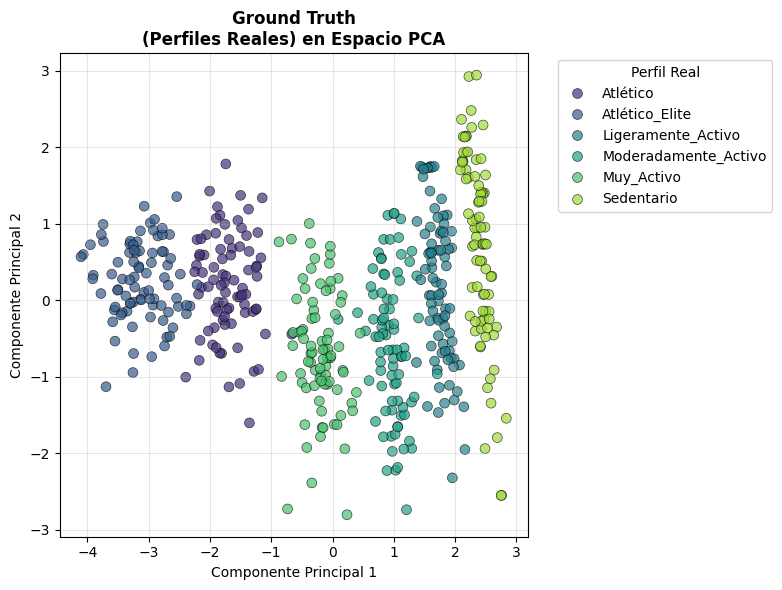

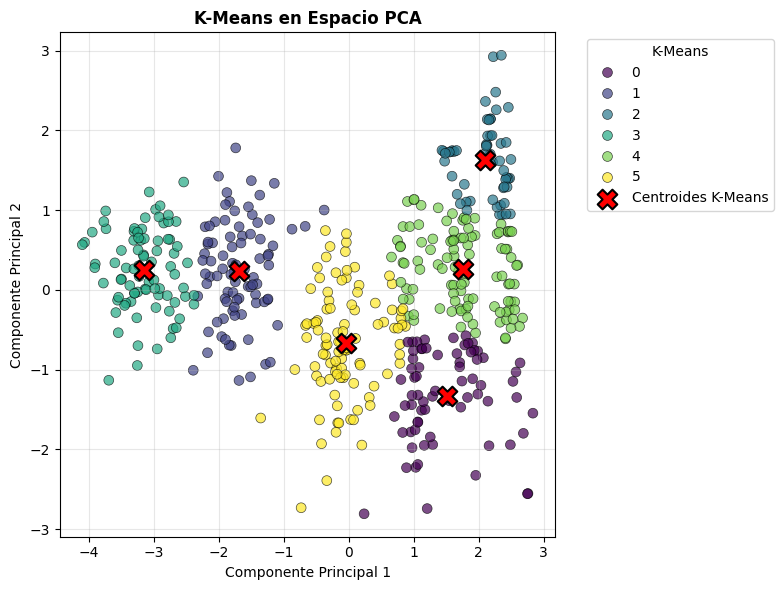

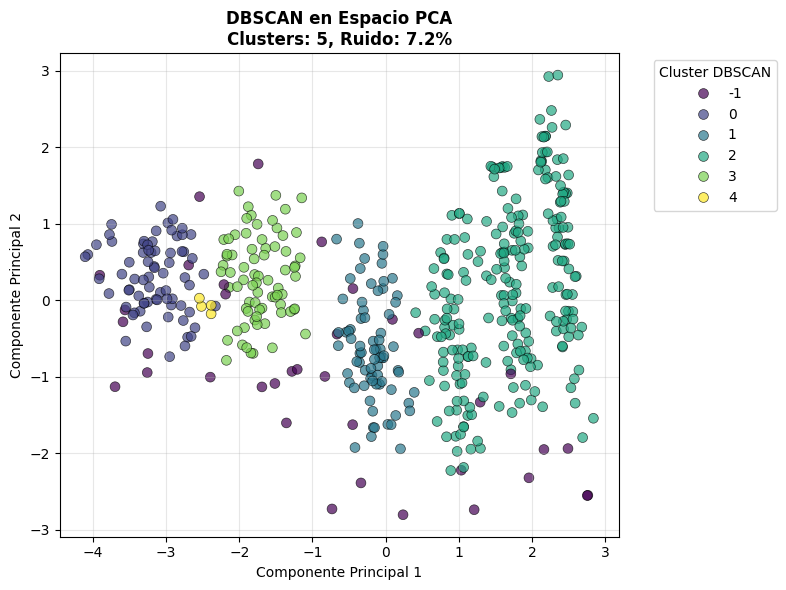

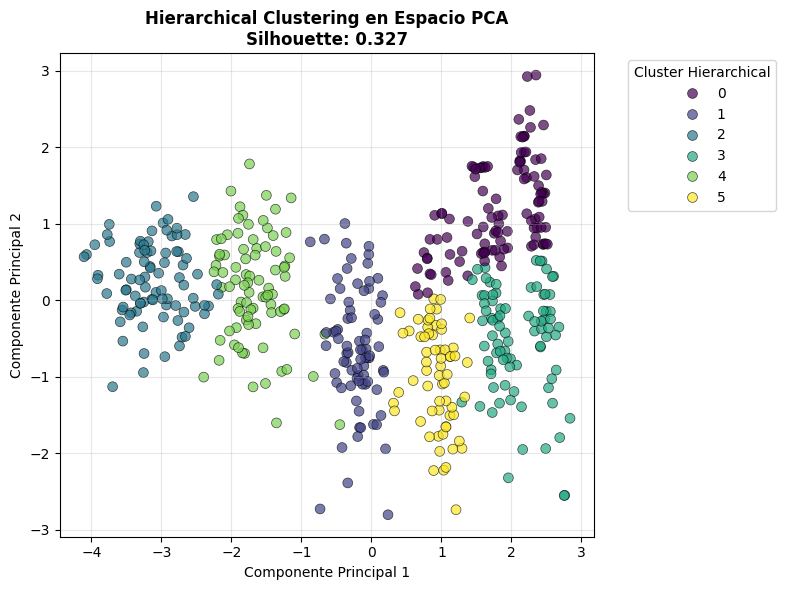


Visualizacion comparativa en espacio PCA completada (figuras independientes).
Varianza explicada por las 2 primeras componentes principales: 0.9634


In [22]:
# Visualización Comparativa de resultados (Continuación - con PCA)

print("\n\nVISUALIZACION COMPARATIVA DE RESULTADOS EN ESPACIO PCA (2D)")
print("="*60)

from sklearn.decomposition import PCA

# Aplicar PCA para reducir a 2 componentes principales
# Se usan los datos escalados (X_scaled) para la reducción de dimensionalidad
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales y las etiquetas de cluster
pca_df = pd.DataFrame(data=X_pca, columns=['PCA_Component_1', 'PCA_Component_2'])
pca_df['perfil_real'] = df['perfil_real'] # Añadir las etiquetas reales (Ground Truth)
pca_df['KMeans_Cluster'] = df['KMeans_Cluster'] # Añadir las etiquetas de K-Means
pca_df['DBSCAN_Cluster'] = df['DBSCAN_Cluster'] # Añadir las etiquetas de DBSCAN
pca_df['Hierarchical_Cluster'] = df['Hierarchical_Cluster'] # Añadir las etiquetas de Hierarchical Clustering

# Definir una paleta de colores diferente, por ejemplo 'viridis' o 'plasma'
palette = 'viridis' # Cambiar a la paleta deseada

# Asegurar suficientes colores para todos los clusters y el ruido de DBSCAN
# Calcular el número máximo de etiquetas únicas en cualquiera de los esquemas de clustering o Ground Truth
dbscan_unique_labels = sorted(df['DBSCAN_Cluster'].unique())
max_unique_labels = max(len(sorted(df['KMeans_Cluster'].unique())),
                         len(dbscan_unique_labels),
                         len(sorted(df['Hierarchical_Cluster'].unique())),
                         df['perfil_real'].nunique())

colors = sns.color_palette(palette, n_colors=max_unique_labels)


# --- Visualización de cada gráfica en una figura independiente ---

# 1. Ground Truth (referencia) en espacio PCA
plt.figure(figsize=(8, 6)) # Figura independiente
ax1 = plt.gca() # Obtener los ejes actuales
sns.scatterplot(data=pca_df, x='PCA_Component_1', y='PCA_Component_2', hue='perfil_real', palette=palette, ax=ax1, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=sorted(pca_df['perfil_real'].unique())) # Ordenar etiquetas reales para consistencia

ax1.set_title('Ground Truth\n(Perfiles Reales) en Espacio PCA', fontweight='bold')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Perfil Real', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 2. K-Means en espacio PCA (Figura Independiente)
plt.figure(figsize=(8, 6)) # Figura independiente
ax2 = plt.gca() # Obtener los ejes actuales
sns.scatterplot(data=pca_df, x='PCA_Component_1', y='PCA_Component_2', hue='KMeans_Cluster', palette=palette, ax=ax2, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=sorted(pca_df['KMeans_Cluster'].unique())) # Ordenar etiquetas K-Means

# --- Agregar centroides de K-Means en espacio PCA ---
# Obtener los centroides escalados del modelo K-Means entrenado
scaled_centroids = kmeans.cluster_centers_
# Aplicar la misma transformación PCA a los centroides escalados para proyectarlos
pca_centroids = pca.transform(scaled_centroids)
# Graficar los centroides en el espacio PCA
ax2.scatter(pca_centroids[:, 0], pca_centroids[:, 1],
           c='red', marker='X', s=200, label='Centroides K-Means',
           edgecolors='black', linewidth=1.5, zorder=10) # zorder para asegurar que se vean por encima de los puntos

# Crear una leyenda combinada para clusters y centroides si es necesario
handles, labels = ax2.get_legend_handles_labels()
# Asegurar que 'Centroides K-Means' esté en la leyenda si no está ya
if 'Centroides K-Means' not in labels:
    # Crear un handle proxy para el centroide si no se agregó automáticamente
    centroid_handle = ax2.scatter([], [], c='red', marker='X', s=200, edgecolors='black', linewidth=1.5)
    handles.append(centroid_handle)
    labels.append('Centroides K-Means')

# Reordenar la leyenda si se desea un orden específico (opcional)
ax2.legend(handles, labels, title='K-Means', bbox_to_anchor=(1.05, 1), loc='upper left')


ax2.set_title('K-Means en Espacio PCA', fontweight='bold')
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. DBSCAN en espacio PCA (Figura Independiente)
plt.figure(figsize=(8, 6)) # Figura independiente
ax3 = plt.gca() # Obtener los ejes actuales
# Visualizar DBSCAN. Se maneja el ruido (-1) en la paleta si es necesario,
# o se confía en seaborn para asignarle un color distinto.
sns.scatterplot(data=pca_df, x='PCA_Component_1', y='PCA_Component_2', hue='DBSCAN_Cluster', palette=palette, ax=ax3, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=dbscan_unique_labels) # Usar el orden de etiquetas único incluyendo -1

title_dbscan = f'DBSCAN en Espacio PCA\nClusters: {n_clusters_dbscan}, Ruido: {noise_percentage:.1f}%'
ax3.set_title(title_dbscan, fontweight='bold')
ax3.set_xlabel('Componente Principal 1')
ax3.set_ylabel('Componente Principal 2')
ax3.grid(True, alpha=0.3)
ax3.legend(title='Cluster DBSCAN', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 4. Hierarchical Clustering en espacio PCA (Figura Independiente)
plt.figure(figsize=(8, 6)) # Figura independiente
ax4 = plt.gca() # Obtener los ejes actuales
# Asegurar que el orden de las etiquetas en la leyenda coincida con el orden de los colores si es necesario
sns.scatterplot(data=pca_df, x='PCA_Component_1', y='PCA_Component_2', hue='Hierarchical_Cluster', palette=palette, ax=ax4, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=sorted(pca_df['Hierarchical_Cluster'].unique())) # Ordenar etiquetas Hierarchical

title_hierarchical = f'Hierarchical Clustering en Espacio PCA\nSilhouette: {hierarchical_silhouette:.3f}'
ax4.set_title(title_hierarchical, fontweight='bold')
ax4.set_xlabel('Componente Principal 1')
ax4.set_ylabel('Componente Principal 2')
ax4.grid(True, alpha=0.3)
ax4.legend(title='Cluster Hierarchical', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


print("\nVisualizacion comparativa en espacio PCA completada (figuras independientes).")
print(f"Varianza explicada por las 2 primeras componentes principales: {pca.explained_variance_ratio_.sum():.4f}")

**Visualización de resultados con (T-SNE)**



📉 VISUALIZACIÓN COMPARATIVA DE RESULTADOS EN ESPACIO T-SNE (2D)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


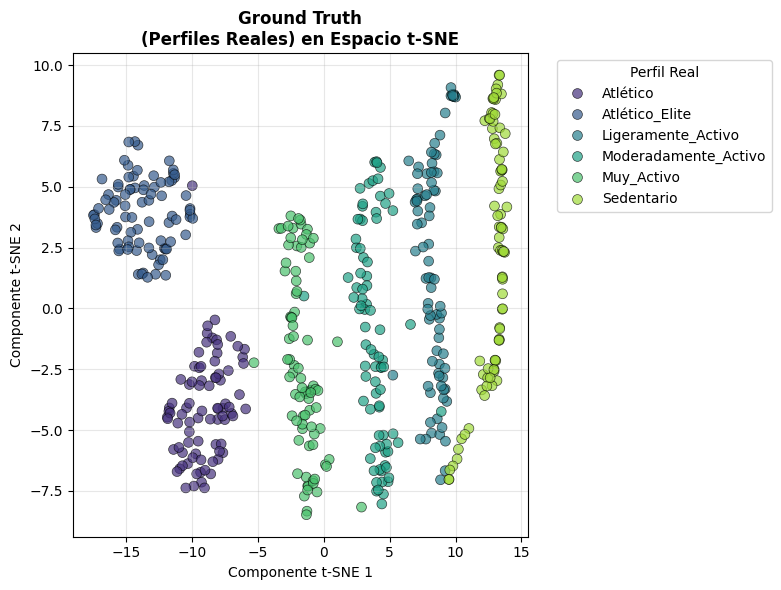

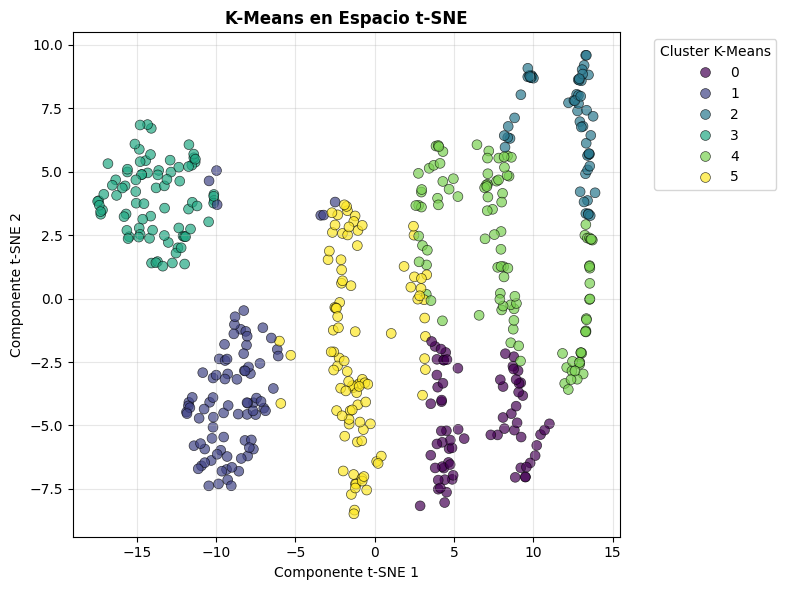

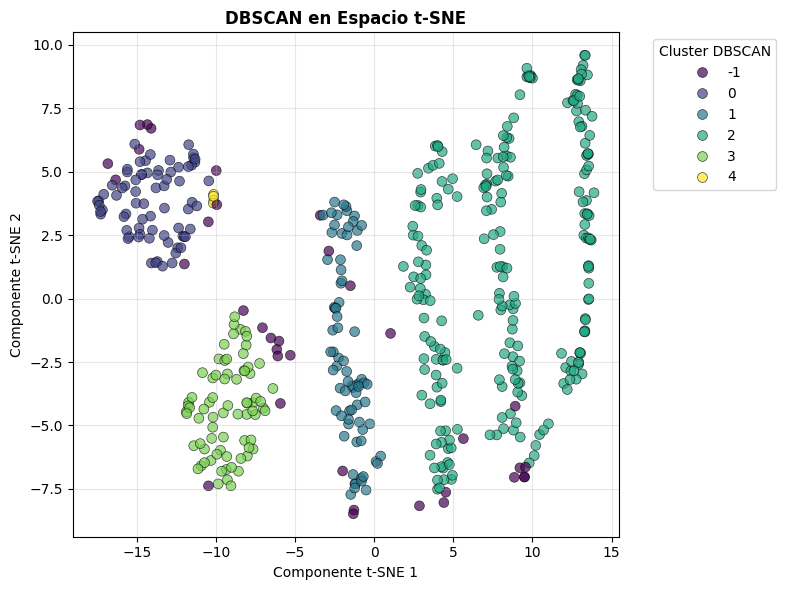

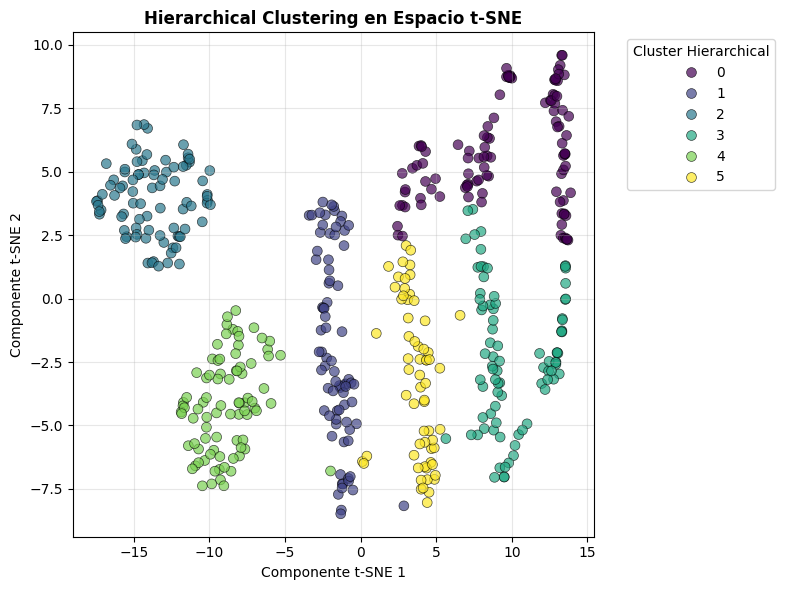


✅ Visualización comparativa en espacio t-SNE completada (figuras independientes).


In [7]:
# Visualización Comparativa de resultados (Continuación - con t-SNE)

print("\n\n📉 VISUALIZACIÓN COMPARATIVA DE RESULTADOS EN ESPACIO T-SNE (2D)")
print("="*60)

from sklearn.manifold import TSNE

# Aplicar t-SNE para reducir a 2 componentes
# t-SNE no tiene un atributo explained_variance_ratio_ como PCA
# Ajustar t-SNE justo antes de usarlo para asegurar el estado correcto
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300) # Parámetros típicos, pueden requerir ajuste
X_tsne = tsne.fit_transform(X_scaled) # Aplicamos t-SNE a los datos escalados (debe ser (n_samples, 5))

# Crear un DataFrame con los componentes t-SNE y las etiquetas de cluster
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE_Component_1', 'TSNE_Component_2'])
tsne_df['perfil_real'] = df['perfil_real'] # Añadir las etiquetas reales
tsne_df['KMeans_Cluster'] = df['KMeans_Cluster'] # Añadir las etiquetas de K-Means
tsne_df['DBSCAN_Cluster'] = df['DBSCAN_Cluster'] # Añadir las etiquetas de DBSCAN
tsne_df['Hierarchical_Cluster'] = df['Hierarchical_Cluster'] # Añadir las etiquetas de Hierarchical Clustering

# Usamos la misma paleta que antes para consistencia, asegurando suficientes colores
# Ajustar el número de colores para incluir el ruido de DBSCAN (-1) y los clusters
n_kmeans_clusters = len(df['KMeans_Cluster'].unique())
n_dbscan_clusters = len(df['DBSCAN_Cluster'].unique())
n_hierarchical_clusters = len(df['Hierarchical_Cluster'].unique())
n_real_clusters = df['perfil_real'].nunique()

max_clusters = max(n_kmeans_clusters, n_dbscan_clusters, n_hierarchical_clusters, n_real_clusters)

# Si DBSCAN encontró ruido (-1), necesitamos un color adicional para él.
dbscan_unique_labels = sorted(df['DBSCAN_Cluster'].unique())
max_unique_labels = max(len(sorted(df['KMeans_Cluster'].unique())),
                         len(dbscan_unique_labels),
                         len(sorted(df['Hierarchical_Cluster'].unique())),
                         df['perfil_real'].nunique())

colors = sns.color_palette('tab10', n_colors=max_unique_labels)


# --- Visualización de cada gráfica en una figura independiente ---

# 1. Ground Truth (referencia) en espacio t-SNE (Figura Independiente)
plt.figure(figsize=(8, 6))
ax1 = plt.gca() # Get current axes
# Aseguramos que el orden de las etiquetas en la leyenda coincida con el orden de los colores si es necesario
sns.scatterplot(data=tsne_df, x='TSNE_Component_1', y='TSNE_Component_2', hue='perfil_real', palette='viridis', ax=ax1, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=sorted(tsne_df['perfil_real'].unique())) # Ordenar etiquetas reales

ax1.set_title('Ground Truth\n(Perfiles Reales) en Espacio t-SNE', fontweight='bold')
ax1.set_xlabel('Componente t-SNE 1')
ax1.set_ylabel('Componente t-SNE 2')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Perfil Real', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 2. K-Means en espacio t-SNE (Figura Independiente)
plt.figure(figsize=(8, 6))
ax2 = plt.gca() # Get current axes
# Aseguramos que el orden de las etiquetas en la leyenda coincida con el orden de los colores si es necesario
sns.scatterplot(data=tsne_df, x='TSNE_Component_1', y='TSNE_Component_2', hue='KMeans_Cluster', palette='viridis', ax=ax2, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=sorted(tsne_df['KMeans_Cluster'].unique())) # Ordenar etiquetas K-Means

# Mostrar solo la leyenda de clusters de K-Means
ax2.legend(title='Cluster K-Means', bbox_to_anchor=(1.05, 1), loc='upper left')


ax2.set_title('K-Means en Espacio t-SNE', fontweight='bold')
ax2.set_xlabel('Componente t-SNE 1')
ax2.set_ylabel('Componente t-SNE 2')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. DBSCAN en espacio t-SNE (Figura Independiente)
plt.figure(figsize=(8, 6))
ax3 = plt.gca() # Get current axes
# Para DBSCAN, manejamos el ruido (-1) explícitamente si es necesario en la paleta,
# o confiamos en seaborn para asignarle un color distinto.
sns.scatterplot(data=tsne_df, x='TSNE_Component_1', y='TSNE_Component_2', hue='DBSCAN_Cluster', palette='viridis', ax=ax3, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                 hue_order=dbscan_unique_labels) # Usar el orden de etiquetas único incluyendo -1

ax3.set_title('DBSCAN en Espacio t-SNE', fontweight='bold')
ax3.set_xlabel('Componente t-SNE 1')
ax3.set_ylabel('Componente t-SNE 2')
ax3.grid(True, alpha=0.3)
ax3.legend(title='Cluster DBSCAN', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 4. Hierarchical Clustering en espacio t-SNE (Figura Independiente)
plt.figure(figsize=(8, 6))
ax4 = plt.gca() # Get current axes
# Aseguramos que el orden de las etiquetas en la leyenda coincida con el orden de los colores si es necesario
sns.scatterplot(data=tsne_df, x='TSNE_Component_1', y='TSNE_Component_2', hue='Hierarchical_Cluster', palette='viridis', ax=ax4, s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                hue_order=sorted(tsne_df['Hierarchical_Cluster'].unique())) # Ordenar etiquetas Hierarchical

ax4.set_title('Hierarchical Clustering en Espacio t-SNE', fontweight='bold')
ax4.set_xlabel('Componente t-SNE 1')
ax4.set_ylabel('Componente t-SNE 2')
ax4.grid(True, alpha=0.3)
ax4.legend(title='Cluster Hierarchical', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


print("\n✅ Visualización comparativa en espacio t-SNE completada (figuras independientes).")
# Nota: t-SNE no tiene una métrica simple de varianza explicada como PCA.

### **Consideración sobre los centroides en t-SNE**

La representación de los centroides de K-Means en un espacio reducido con t-SNE debe interpretarse con cuidado.  

En PCA, al ser una transformación lineal, los centroides se proyectan de forma coherente y predecible. En cambio, **t-SNE es no lineal y prioriza relaciones de vecindad**, lo que implica que la función `transform` no necesariamente ubica puntos nuevos (como centroides) en posiciones que reflejen con claridad la estructura observada en los datos originales.  

Incluso, en algunos escenarios, el uso de `tsne.transform` sobre centroides puede producir resultados inconsistentes o errores si estos se encuentran alejados de la nube de datos original en el espacio de mayor dimensión.  

Por ello, aunque la proyección de centroides es válida y útil en PCA, en t-SNE su aporte visual puede ser limitado o inducir interpretaciones erróneas.  


**5) Evaluación de metricas**

In [23]:
# Acción No. 5: Evaluación de Métricas

print("\n\nEVALUACION DE METRICAS DE CLUSTERING")
print("=" * 60)

print("TABLA COMPARATIVA DE METRICAS")
print("=" * 60)

# Crear DataFrame con métricas comunes
# Asegurarnos de usar los nombres de variables correctos del notebook
metrics_comparison = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette Score': [kmeans_silhouette,
                        dbscan_silhouette if not np.isnan(dbscan_silhouette) else np.nan, # Usar np.isnan para verificar si la métrica fue calculada
                        hierarchical_silhouette],
    'Davies-Bouldin Index': [kmeans_db_score,
                           dbscan_db_score if not np.isnan(dbscan_db_score) else np.nan, # Usar np.isnan para verificar si la métrica fue calculada
                           hierarchical_db_score],
    'Calinski-Harabasz Index': [kmeans_ch_score,
                              dbscan_ch_score if not np.isnan(dbscan_ch_score) else np.nan, # Usar np.isnan para verificar si la métrica fue calculada
                              hierarchical_ch_score],
    'Clusters Detectados': [kmeans.n_clusters, n_clusters_dbscan, hierarchical.n_clusters] # Usar los n_clusters reales de los modelos
})

print("METRICAS COMUNES (para comparación directa):")
display(metrics_comparison.round(4))

print("\n" + "=" * 60)
print("METRICAS ESPECIFICAS POR ALGORITMO:")
print("=" * 60)

print("\nK-MEANS:")
# Asegurarnos de usar los nombres de variables correctos del notebook
print(f"   WCSS (Within-Cluster SS): {kmeans_wcss:.4f}")
print(f"   BCSS (Between-Cluster SS): {kmeans_bcss:.4f}")
# Evitar división por cero si WCSS es 0 (aunque improbable en este caso)
if kmeans_wcss > 1e-6:
    print(f"   Ratio BCSS/WCSS: {(kmeans_bcss/kmeans_wcss):.4f}")
else:
    print("   Ratio BCSS/WCSS: Indefinido (WCSS muy cercano a cero)")
print(f"   Iteraciones: {kmeans.n_iter_}")

print("\nDBSCAN:")
# Asegurarnos de usar los nombres de variables correctos del notebook
print(f"   Clusters encontrados: {n_clusters_dbscan}")
print(f"   Puntos de ruido: {n_noise} ({noise_percentage:.1f}%)")
print(f"   Puntos validos: {len(X_scaled) - n_noise} ({100-noise_percentage:.1f}%)") # Usar X_scaled para el total de puntos
print(f"   Parametros: eps={dbscan.eps}, min_samples={dbscan.min_samples}")

print("\nHIERARCHICAL:")
# Asegurarnos de usar los nombres de variables correctos del notebook
print(f"   Correlacion Cofenetica: {cophenet_corr:.4f}")
print(f"   Metodo de enlace: {hierarchical.linkage}")
print(f"   Calidad estructura jerarquica: ", end="")
if cophenet_corr > 0.8:
    print("Excelente")
elif cophenet_corr > 0.7:
    print("Buena")
elif cophenet_corr > 0.6:
    print("Aceptable")
else:
    print("Cuestionable")

print("\n" + "=" * 60)
print("INTERPRETACION DE METRICAS:")
print("=" * 60)
print("Silhouette Score: [-1, 1] -> Mas alto es mejor")
print("Davies-Bouldin Index: [0, ∞) -> Mas bajo es mejor")
print("Calinski-Harabasz Index: [0, ∞) -> Mas alto es mejor")
print("Correlacion Cofenetica: [0, 1] -> Mas alto es mejor (para jerarquico)")


# Ranking simple basado en métricas válidas
print(f"\nRANKING BASADO EN METRICAS (considerando aplicabilidad):")

# Ranking Silhouette Score (Más alto es mejor)
print(f"\n   Ranking Silhouette Score (Mas alto es mejor):")
# Filtrar DBSCAN si Silhouette fue NaN
ranking_silhouette_df = metrics_comparison.dropna(subset=['Silhouette Score']).sort_values('Silhouette Score', ascending=False)
if not ranking_silhouette_df.empty:
    for i, (_, row) in enumerate(ranking_silhouette_df.iterrows(), 1):
        print(f"      {i}. {row['Algoritmo']}: {row['Silhouette Score']:.4f}")
else:
    print("      No hay algoritmos con Silhouette Score valido para ranking.")

# Ranking Davies-Bouldin Index (Más bajo es mejor)
print(f"\n   Ranking Davies-Bouldin Index (Mas bajo es mejor):")
# Filtrar DBSCAN si Davies-Bouldin fue NaN
ranking_db_df = metrics_comparison.dropna(subset=['Davies-Bouldin Index']).sort_values('Davies-Bouldin Index', ascending=True)
if not ranking_db_df.empty:
    for i, (_, row) in enumerate(ranking_db_df.iterrows(), 1):
        print(f"      {i}. {row['Algoritmo']}: {row['Davies-Bouldin Index']:.4f}")
else:
    print("      No hay algoritmos con Davies-Bouldin Index valido para ranking.")

# Ranking Calinski-Harabasz Index (Más alto es mejor)
print(f"\n   Ranking Calinski-Harabasz Index (Mas alto es mejor):")
# Filtrar DBSCAN si Calinski-Harabasz fue NaN
ranking_ch_df = metrics_comparison.dropna(subset=['Calinski-Harabasz Index']).sort_values('Calinski-Harabasz Index', ascending=False)
if not ranking_ch_df.empty:
    for i, (_, row) in enumerate(ranking_ch_df.iterrows(), 1):
        print(f"      {i}. {row['Algoritmo']}: {row['Calinski-Harabasz Index']:.1f}")
else:
     print("      No hay algoritmos con Calinski-Harabasz Index valido para ranking.")


print("\nEvaluacion de Metricas completada.")



EVALUACION DE METRICAS DE CLUSTERING
TABLA COMPARATIVA DE METRICAS
METRICAS COMUNES (para comparación directa):


,Algoritmo,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Clusters Detectados
0,K-Means,0.3340,1.0015,603.3561,6
1,DBSCAN,0.3147,0.9099,367.1804,5
2,Hierarchical,0.3266,1.1171,552.3278,6



METRICAS ESPECIFICAS POR ALGORITMO:

K-MEANS:
   WCSS (Within-Cluster SS): 351.7736
   BCSS (Between-Cluster SS): 2148.2264
   Ratio BCSS/WCSS: 6.1068
   Iteraciones: 10

DBSCAN:
   Clusters encontrados: 5
   Puntos de ruido: 36 (7.2%)
   Puntos validos: 464 (92.8%)
   Parametros: eps=0.5, min_samples=5

HIERARCHICAL:
   Correlacion Cofenetica: 0.7617
   Metodo de enlace: ward
   Calidad estructura jerarquica: Buena

INTERPRETACION DE METRICAS:
Silhouette Score: [-1, 1] -> Mas alto es mejor
Davies-Bouldin Index: [0, ∞) -> Mas bajo es mejor
Calinski-Harabasz Index: [0, ∞) -> Mas alto es mejor
Correlacion Cofenetica: [0, 1] -> Mas alto es mejor (para jerarquico)

RANKING BASADO EN METRICAS (considerando aplicabilidad):

   Ranking Silhouette Score (Mas alto es mejor):
      1. K-Means: 0.3340
      2. Hierarchical: 0.3266
      3. DBSCAN: 0.3147

   Ranking Davies-Bouldin Index (Mas bajo es mejor):
      1. DBSCAN: 0.9099
      2. K-Means: 1.0015
      3. Hierarchical: 1.1171

   Rankin

**Visualización comparativa de metricas**

VISUALIZACION COMPARATIVA DE METRICAS


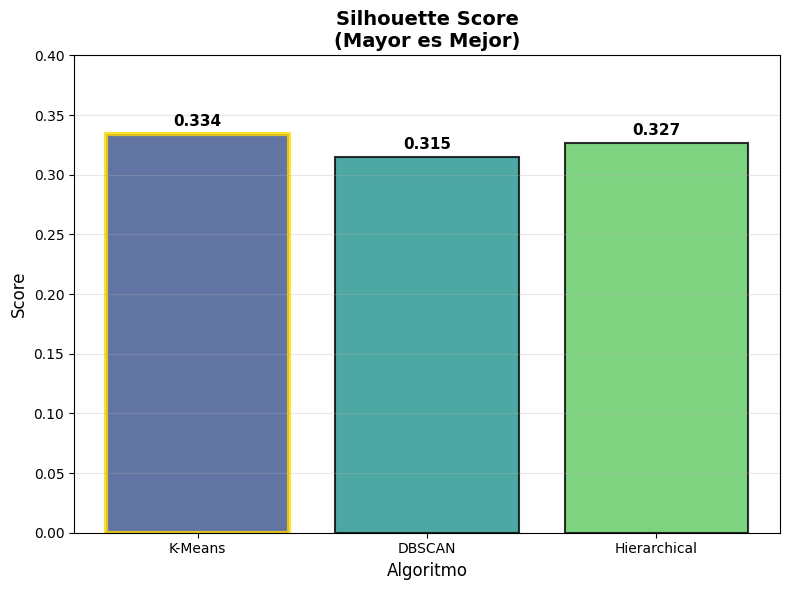

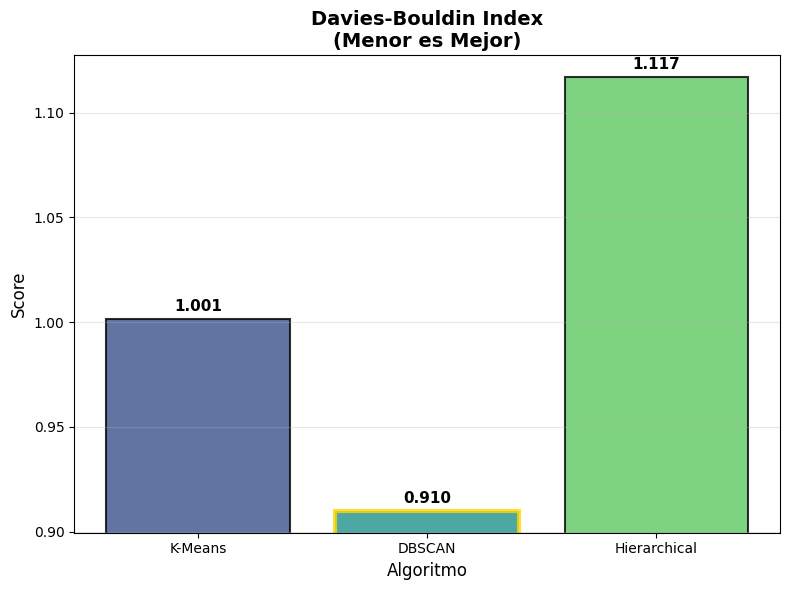

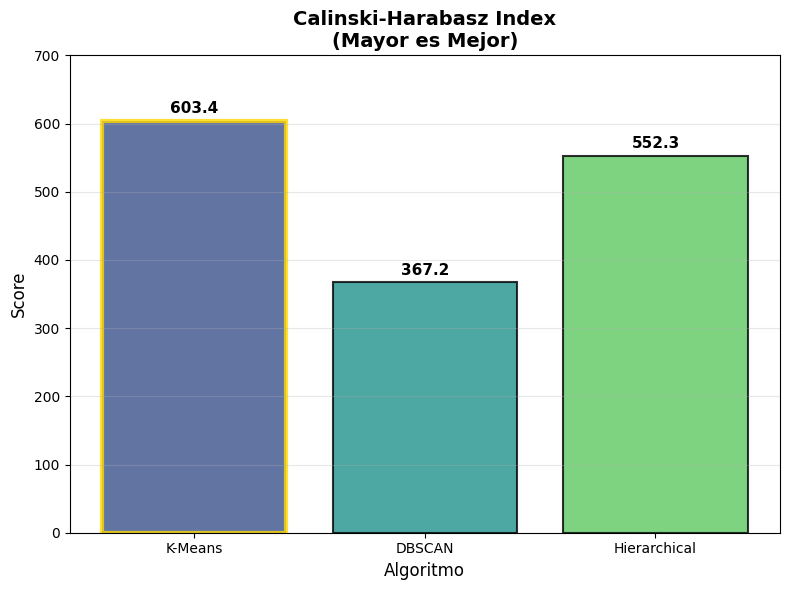


ANALISIS ESTADISTICO DETALLADO:
Mejor Silhouette Score: K-Means (0.3340)
Mejor Davies-Bouldin: DBSCAN (0.9099)
Mejor Calinski-Harabasz: K-Means (603.4)

RANKING GENERAL (numero de metricas donde es mejor):
   K-Means: 2/3 metricas
   DBSCAN: 1/3 metricas
   Hierarchical: 0/3 metricas

INTERPRETACION VISUAL:
Bordes dorados indican el mejor algoritmo para cada metrica
Silhouette y Calinski-Harabasz: barras mas altas son mejores
Davies-Bouldin: barras mas bajas son mejores
N/A (rojo) indica que el algoritmo no produjo clusters validos

Evaluacion de Metricas completada.


In [25]:
# Visualización comparativa de métricas de clustering

print("VISUALIZACION COMPARATIVA DE METRICAS")
print("=" * 50)

# Preparar datos para visualización
algorithms = ['K-Means', 'DBSCAN', 'Hierarchical']
# Cambiar esquema de color a 'viridis' para consistencia con visualizaciones anteriores
colors_algo = sns.color_palette('viridis', n_colors=len(algorithms))


# Métricas comunes (usamos los valores calculados, que ya son np.nan si no aplican para DBSCAN)
silhouette_scores = [
    kmeans_silhouette,
    dbscan_silhouette,
    hierarchical_silhouette
]

davies_bouldin_scores = [
    kmeans_db_score,
    dbscan_db_score,
    hierarchical_db_score
]

calinski_harabasz_scores = [
    kmeans_ch_score,
    dbscan_ch_score,
    hierarchical_ch_score
]

# --- Función auxiliar para manejar límites del eje Y con NaNs usando np.nanmin/nanmax (para barras verticales) ---
# Esta función ayuda a establecer los límites del eje Y de forma dinámica, manejando valores NaN.
# Mantenemos la función pero la adaptamos o usamos set_ylim directamente si el usuario especifica límites
def set_ylim_handling_nan_vertical(ax, scores, is_lower_better=False, padding=0.05, upper_padding_factor=1.0):
    # Convertir a numpy array para usar nanmin/nanmax
    scores_np = np.array(scores, dtype=float)

    # Verificar si hay al menos un valor no-NaN
    if np.isnan(scores_np).all():
         ax.set_ylim(0, 1) # Default limits if all scores are NaN
         return

    min_score = np.nanmin(scores_np)
    max_score = np.nanmax(scores_np)

    # Aumentar el padding superior usando el factor para dejar espacio al texto
    upper_padding = padding * upper_padding_factor
    lower_padding = padding

    # Calcular el rango de los valores válidos
    score_range = max_score - min_score if max_score != min_score else 1 # Evitar división por cero si todos los valores válidos son iguales


    if is_lower_better: # For metrics where lower is better (like Davies-Bouldin)
        # Ensure min is not below 0
        ax.set_ylim(max(0.0, min_score - lower_padding * score_range), max_score + upper_padding * score_range) # Asegurarse de que el límite inferior no sea negativo
    else: # For metrics where higher is better (like Silhouette, Calinski-Harabasz)
         # Ensure max is not above 1 for Silhouette if applicable
        upper_limit = max_score + upper_padding * score_range
        ax.set_ylim(min(0.0, min_score - lower_padding * score_range), upper_limit) # Asegurarse de que el límite inferior no sea negativo


# 1. Silhouette Score (Mayor es mejor) - Vertical Bar Chart (Figura Independiente)
plt.figure(figsize=(8, 6)) # Ajustar tamaño para figura individual
ax1 = plt.gca() # Get current axes
bars1 = ax1.bar(algorithms, silhouette_scores, color=colors_algo, alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax1.set_title('Silhouette Score\n(Mayor es Mejor)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Score', fontsize=12) # Eje Y es el score
ax1.set_xlabel('Algoritmo', fontsize=12) # Eje X son los algoritmos
# Establecer límites del eje Y manualmente según la solicitud del usuario
ax1.set_ylim(0.0, 0.40) # Límite inferior 0, superior 0.40
ax1.grid(True, alpha=0.3, axis='y') # Cuadrícula en eje Y para barras verticales

# Agregar valores al final de las barras
for i, bar in enumerate(bars1):
    score = silhouette_scores[i]
    if not np.isnan(score):
        # Posicionar el texto ligeramente por encima de la barra con un offset fijo
        y_text_pos = bar.get_height() + (ax1.get_ylim()[1]-ax1.get_ylim()[0])*0.01 # Usar un porcentaje del rango Y para offset
        ax1.text(bar.get_x() + bar.get_width()/2, y_text_pos,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    else:
        # Posicionar N/A cerca del mínimo del eje Y actual
        ax1.text(i, ax1.get_ylim()[0] + (ax1.get_ylim()[1]-ax1.get_ylim()[0])*0.05,
                 'N/A', ha='center', va='bottom', fontweight='bold',
                fontsize=11, color='red')


# Resaltar el mejor valor
if not all(np.isnan(silhouette_scores)):
    # Usar nanargmax para ignorar NaN al encontrar el índice máximo
    best_idx = np.nanargmax(silhouette_scores)
    bars1[best_idx].set_edgecolor('gold')
    bars1[best_idx].set_linewidth(3)

plt.tight_layout()
plt.show()


# 2. Davies-Bouldin Index (Menor es mejor) - Vertical Bar Chart (Figura Independiente)
plt.figure(figsize=(8, 6)) # Ajustar tamaño para figura individual
ax2 = plt.gca() # Get current axes
bars2 = ax2.bar(algorithms, davies_bouldin_scores, color=colors_algo, alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax2.set_title('Davies-Bouldin Index\n(Menor es Mejor)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Score', fontsize=12) # Eje Y es el score
ax2.set_xlabel('Algoritmo', fontsize=12) # Eje X son los algoritmos
# Usar la función auxiliar para establecer límites del eje Y (padding estándar)
set_ylim_handling_nan_vertical(ax2, davies_bouldin_scores, is_lower_better=True, padding=0.05) # Usamos padding automático para este
ax2.grid(True, alpha=0.3, axis='y') # Cuadrícula en eje Y

# Agregar valores al final de las barras
for i, bar in enumerate(bars2):
    score = davies_bouldin_scores[i]
    if not np.isnan(score):
        # Posicionar el texto ligeramente por encima de la barra con un offset fijo
        y_text_pos = bar.get_height() + (ax2.get_ylim()[1]-ax2.get_ylim()[0])*0.01 # Usar un porcentaje del rango Y para offset
        ax2.text(bar.get_x() + bar.get_width()/2, y_text_pos,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    else:
         # Posicionar N/A cerca del mínimo del eje Y actual
        ax2.text(i, ax2.get_ylim()[0] + (ax2.get_ylim()[1]-ax2.get_ylim()[0])*0.05,
                 'N/A', ha='center', va='bottom', fontweight='bold',
                fontsize=11, color='red')

# Resaltar el mejor valor (menor)
if not all(np.isnan(davies_bouldin_scores)):
    # Usar nanargmin para ignorar NaN al encontrar el índice mínimo
    best_idx = np.nanargmin(davies_bouldin_scores)
    bars2[best_idx].set_edgecolor('gold')
    bars2[best_idx].set_linewidth(3)

plt.tight_layout()
plt.show()


# 3. Calinski-Harabasz Index (Mayor es mejor) - Vertical Bar Chart (Figura Independiente)
plt.figure(figsize=(8, 6)) # Ajustar tamaño para figura individual
ax3 = plt.gca() # Get current axes
bars3 = ax3.bar(algorithms, calinski_harabasz_scores, color=colors_algo, alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax3.set_title('Calinski-Harabasz Index\n(Mayor es Mejor)', fontweight='bold', fontsize=14)
ax3.set_ylabel('Score', fontsize=12) # Eje Y es el score
ax3.set_xlabel('Algoritmo', fontsize=12) # Eje X son los algoritmos
# Establecer límites del eje Y manualmente según la solicitud del usuario
ax3.set_ylim(0.0, 700.0) # Límite inferior 0, superior 700
ax3.grid(True, alpha=0.3, axis='y') # Cuadrícula en eje Y

# Agregar valores al final de las barras
for i, bar in enumerate(bars3):
    score = calinski_harabasz_scores[i]
    if not np.isnan(score):
        # Posicionar el texto ligeramente por encima de la barra con un offset fijo
        y_text_pos = bar.get_height() + (ax3.get_ylim()[1]-ax3.get_ylim()[0])*0.01 # Usar un porcentaje del rango Y para offset
        ax3.text(bar.get_x() + bar.get_width()/2, y_text_pos,
                f'{score:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    else:
         # Posicionar N/A cerca del mínimo del eje Y actual
        ax3.text(i, ax3.get_ylim()[0] + (ax3.get_ylim()[1]-ax3.get_ylim()[0])*0.05,
                 'N/A', ha='center', va='bottom', fontweight='bold',
                fontsize=11, color='red')


# Resaltar el mejor valor
if not all(np.isnan(calinski_harabasz_scores)):
    # Usar nanargmax para ignorar NaN al encontrar el índice máximo
    best_idx = np.nanargmax(calinski_harabasz_scores)
    bars3[best_idx].set_edgecolor('gold')
    bars3[best_idx].set_linewidth(3)


# Ajustar diseño
plt.tight_layout()
plt.show()

# Análisis estadístico detallado
print("\nANALISIS ESTADISTICO DETALLADO:")
print("=" * 50)

# Encontrar mejores algoritmos por cada métrica
valid_algorithms = []
valid_silhouette = []
valid_db = []
valid_ch = []

for i, algo in enumerate(algorithms):
    # Solo considerar algoritmos con métricas válidas para el ranking
    if not np.isnan(silhouette_scores[i]) and not np.isnan(davies_bouldin_scores[i]) and not np.isnan(calinski_harabasz_scores[i]):
         valid_algorithms.append(algo)
         valid_silhouette.append(silhouette_scores[i])
         valid_db.append(davies_bouldin_scores[i])
         valid_ch.append(calinski_harabasz_scores[i])


if valid_algorithms: # Asegurarse de que hay algoritmos válidos para el ranking
    # Mejores por métrica
    best_sil_idx = np.argmax(valid_silhouette)
    best_db_idx = np.argmin(valid_db)
    best_ch_idx = np.argmax(valid_ch)

    print(f"Mejor Silhouette Score: {valid_algorithms[best_sil_idx]} ({valid_silhouette[best_sil_idx]:.4f})")
    print(f"Mejor Davies-Bouldin: {valid_algorithms[best_db_idx]} ({valid_db[best_db_idx]:.4f})")
    print(f"Mejor Calinski-Harabasz: {valid_algorithms[best_ch_idx]} ({valid_ch[best_ch_idx]:.1f})")

    # Conteo de "victorias"
    wins = {algo: 0 for algo in valid_algorithms}
    wins[valid_algorithms[best_sil_idx]] += 1
    wins[valid_algorithms[best_db_idx]] += 1
    wins[valid_algorithms[best_ch_idx]] += 1

    print(f"\nRANKING GENERAL (numero de metricas donde es mejor):")
    # Ordenar por número de victorias descendente
    for algo, win_count in sorted(wins.items(), key=lambda x: x[1], reverse=True):
        print(f"   {algo}: {win_count}/3 metricas")
else:
    print("No hay suficientes algoritmos con metricas validas para realizar un ranking comparativo.")


print(f"\nINTERPRETACION VISUAL:")
print("Bordes dorados indican el mejor algoritmo para cada metrica")
print("Silhouette y Calinski-Harabasz: barras mas altas son mejores")
print("Davies-Bouldin: barras mas bajas son mejores")
print("N/A (rojo) indica que el algoritmo no produjo clusters validos")

print("\nEvaluacion de Metricas completada.")

#### **Dendrograma del Clustering Jerárquico**

ANALISIS DEL DENDROGRAMA - HIERARCHICAL CLUSTERING


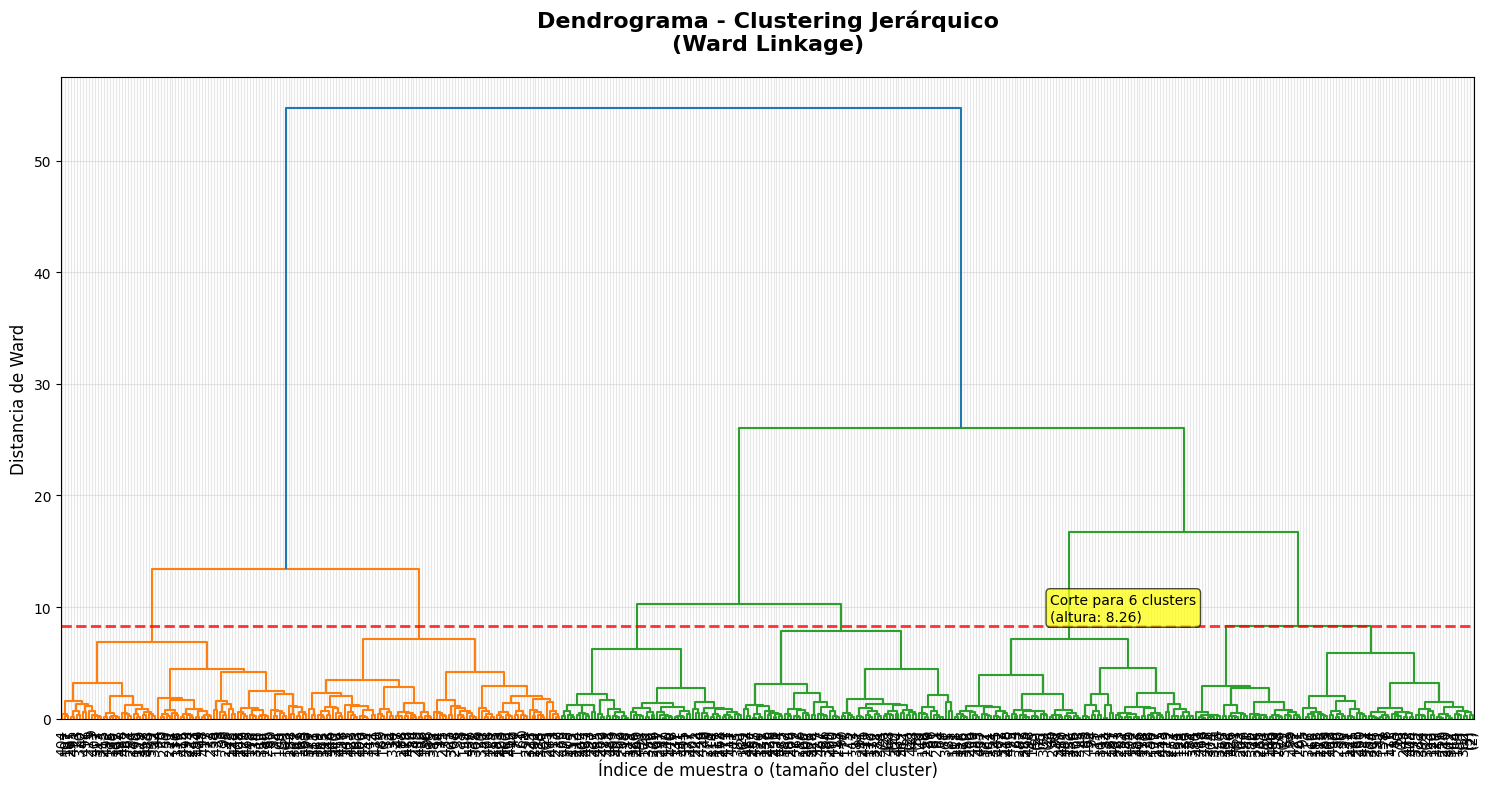


ANALISIS DEL DENDROGRAMA:
Correlacion Cofenetica: 0.7617
Altura de corte para 6 clusters: 8.2576
Metodo de enlace: Ward (minimiza varianza)

ULTIMAS 5 FUSIONES (mas relevantes):
Paso | Cluster1 | Cluster2 | Distancia | Tamaño
--------------------------------------------------
 495 |      988 |      992 |     10.26 |    141
 496 |      989 |      990 |     13.42 |    170
 497 |      991 |      993 |     16.77 |    189
 498 |      994 |      996 |     26.08 |    330
 499 |      995 |      997 |     54.72 |    500

INTERPRETACION:
El dendrograma muestra la estructura jerarquica de agrupacion
La altura indica la distancia a la que se unen los clusters
La linea roja muestra un posible corte para obtener 6 clusters (altura: 8.26)
Correlacion cofenetica 0.762 indica buena preservacion de distancias
Adjusted Rand Index (ARI) vs Ground Truth: 0.6696
El ARI mide la similitud entre dos agrupaciones, ignorando permutaciones de etiquetas.
Un ARI de 1.0 indica que las agrupaciones son identicas.
Un

In [26]:
# Dendograma

print("ANALISIS DEL DENDROGRAMA - HIERARCHICAL CLUSTERING")
print("=" * 60)

# Crear el dendrograma
plt.figure(figsize=(15, 8))

dendro = dendrogram(linkage_matrix,
                   truncate_mode='level',  # Truncar por nivel
                   p=10,  # Mostrar solo los últimos 10 niveles (ajustar p según el tamaño del dataset si es muy grande)
                   leaf_rotation=90,
                   leaf_font_size=10,
                   show_leaf_counts=True)

plt.title('Dendrograma - Clustering Jerárquico\n(Ward Linkage)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Índice de muestra o (tamaño del cluster)', fontsize=12)
plt.ylabel('Distancia de Ward', fontsize=12)

# Si queremos mostrar el corte para 6 clusters (como en AgglomerativeClustering):
try:
    # Encontrar la altura donde se forman 6 clusters (la 6ta fusión desde el final)
    cut_height_6 = linkage_matrix[-hierarchical.n_clusters, 2] # Usar n_clusters del modelo

    plt.axhline(y=cut_height_6, color='red', linestyle='--', alpha=0.8, linewidth=2)
    # Posicionar el texto de forma relativa al gráfico
    x_text_pos = plt.xlim()[0] + (plt.xlim()[1] - plt.xlim()[0]) * 0.7 # 70% del ancho del gráfico
    y_text_pos = cut_height_6 + (plt.ylim()[1]-plt.ylim()[0])*0.01 # Un pequeño offset sobre la línea de corte
    plt.text(x_text_pos, y_text_pos,
             f'Corte para {hierarchical.n_clusters} clusters\n(altura: {cut_height_6:.2f})', # Usar n_clusters del modelo
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

except IndexError:
    print("No se pudieron encontrar suficientes fusiones para mostrar el corte para 6 clusters.")
    cut_height_6 = np.nan # O manejar el error de otra forma


plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Análisis del dendrograma
print("\nANALISIS DEL DENDROGRAMA:")
print("=" * 40)
# cophenet_corr ya fue calculada en la celda anterior
print(f"Correlacion Cofenetica: {cophenet_corr:.4f}")
if not np.isnan(cut_height_6):
    print(f"Altura de corte para {hierarchical.n_clusters} clusters: {cut_height_6:.4f}") # Usar n_clusters del modelo
print(f"Metodo de enlace: Ward (minimiza varianza)")

# Mostrar las últimas fusiones (más informativas)
print(f"\nULTIMAS 5 FUSIONES (mas relevantes):")
print("Paso | Cluster1 | Cluster2 | Distancia | Tamaño")
print("-" * 50)
# Asegurarse de que hay al menos 5 fusiones para mostrar
num_fusiones = len(linkage_matrix)
start_index = max(0, num_fusiones - 5) # Empezar 5 pasos antes del final, o desde el inicio si hay menos de 5

for i in range(start_index, num_fusiones):
    step = i + 1 # Paso de fusión (empezando desde 1)
    cluster1, cluster2, distance, size = linkage_matrix[i]
    print(f"{step:4d} | {int(cluster1):8d} | {int(cluster2):8d} | {distance:9.2f} | {int(size):6d}")


# Interpretación y comparación con Ground Truth (código proporcionado por el usuario)
print(f"\nINTERPRETACION:")
print("El dendrograma muestra la estructura jerarquica de agrupacion")
print("La altura indica la distancia a la que se unen los clusters")
# Ajustar la descripción de la línea roja según el corte que se muestre (actualmente para 6 clusters)
if not np.isnan(cut_height_6):
    print(f"La linea roja muestra un posible corte para obtener {hierarchical.n_clusters} clusters (altura: {cut_height_6:.2f})") # Usar n_clusters del modelo
else:
     print("No se pudo mostrar la altura de corte para el numero de clusters especificado.")

print(f"Correlacion cofenetica {cophenet_corr:.3f} indica ", end="")
if cophenet_corr > 0.8:
    print("excelente preservacion de distancias")
elif cophenet_corr > 0.7:
    print("buena preservacion de distancias")
else:
    print("preservacion de distancias cuestionable")

# Comparar clusters jerárquicos vs ground truth usando Adjusted Rand Index (código proporcionado por el usuario)
# y_true y hierarchical_labels ya están disponibles
from sklearn.metrics import adjusted_rand_score
ari_hierarchical = adjusted_rand_score(y_true, hierarchical_labels)
print(f"Adjusted Rand Index (ARI) vs Ground Truth: {ari_hierarchical:.4f}")
print("El ARI mide la similitud entre dos agrupaciones, ignorando permutaciones de etiquetas.")
print("Un ARI de 1.0 indica que las agrupaciones son identicas.")
print("Un ARI cercano a 0 indica que la similitud es aleatoria.")
print("Un ARI negativo indica menor similitud que la esperada por azar.")

print("\nAnalisis del dendrograma y comparacion con Ground Truth completados.")

# **Seccion de preguntas**

# **Preguntas sobre K-Means Clustering**

1) **Inicialización de centroides**  
   Si un centroide cae muy cerca del grupo "Sedentario" y otro entre "Atlético" y "Atlético Elite", la segmentación inicial puede sesgar el algoritmo. Esto puede generar clusters poco representativos, ya que K-Means depende fuertemente de la posición inicial de los centroides. Como consecuencia, los perfiles finales de usuarios podrían mezclarse o no reflejar patrones reales de actividad.  

2) **Escalas diferentes en las variables**  
   Dado que las variables están en distintas magnitudes (miles de pasos vs. horas de sueño vs. minutos de ejercicio), si no se estandarizan, dominarán aquellas con valores numéricamente mayores. En este caso, **los pasos diarios** serían la variable principal en la formación de clusters, desplazando la influencia de las demás.  

3) **Supuesto de clusters esféricos**  
   K-Means trabaja bajo la suposición de clusters con forma esférica y sin correlaciones complejas. En datos de actividad física, donde las variables pueden estar correlacionadas (ej. frecuencia cardíaca y duración del ejercicio), este supuesto se rompe.  
   - Si un usuario "Muy Activo" termina en el cluster "Moderadamente Activo", no necesariamente es un error de implementación, sino una **limitación inherente de K-Means** al no manejar formas de clusters más complejas.  


# **Preguntas sobre DBSCAN**

4) **Parámetros ε y min_samples**  
   - Si ε es demasiado pequeño, usuarios "Atlético Elite" podrían marcarse como *outliers*, perdiendo información sobre deportistas de alto rendimiento.  
   - Si ε es demasiado grande, grupos distintos como "Sedentarios" y "Ligeramente Activos" podrían fusionarse.  
   - Para justificar parámetros en un comité de salud pública, se deben usar **criterios del dominio**, como:  
     - Recomendaciones de la OMS sobre pasos y ejercicio.  
     - Umbrales médicos de frecuencia cardíaca en reposo.  
     - Rangos de sueño asociados a bajo o alto riesgo en salud.  

5) **Distribución de usuarios en poblaciones reales**  
   Dado que hay más "Sedentarios" y "Moderadamente Activos" que "Atlético Elite", existe riesgo de que DBSCAN:  
   - Favorezca la detección de clusters grandes.  
   - Clasifique grupos minoritarios pero relevantes (ej. "Atlético Elite") como ruido, reduciendo la capacidad de detectar perfiles de alto interés en salud.  

6) **Usuarios clasificados como ruido (~15%)**  
   Estos casos pueden incluir:  
   - (a) Usuarios con patrones raros pero válidos.  
   - (b) Registros con errores de sensores o medición.  
   - (c) Individuos en transición de hábitos.  

   **Implicaciones éticas:** descartarlos en una aplicación de salud digital significaría invisibilizar poblaciones relevantes, eliminar posibles detecciones tempranas de riesgo o ignorar a usuarios en proceso de mejora. Podría llevar a recomendaciones sesgadas y discriminatorias.  


# **Preguntas sobre Clustering Jerárquico**

7) **Elección de métricas de distancia**  
   - Euclidiana: dominada por variables con valores altos (ej. pasos diarios).  
   - Manhattan: más sensible a variables con valores bajos (ej. horas de sueño).  
   - Coseno: útil cuando importa la forma del patrón más que la magnitud.  
   - Argumento: la métrica debe seleccionarse según la hipótesis de interés. En salud, distintos enfoques pueden revelar patrones complementarios (ej. balance entre sueño y actividad).  

8) **Decisión sobre el número de clusters**  
   Si el dendrograma permite justificar varios cortes (4, 5, 6 o 7 clusters), la elección debe apoyarse en criterios metodológicos como:  
   - Índices de validación interna (Silhouette, Davies-Bouldin).  
   - Estabilidad de clusters ante pequeñas perturbaciones de los datos.  
   - Interpretabilidad clínica o de comportamiento.  
   Así, si la empresa requiere 5 segmentos, se puede defender esa elección mostrando que mantiene equilibrio entre validez estadística y coherencia interpretativa.  

9) **Problemas de la jerarquía forzada**  
   En clustering jerárquico, un cluster superior incluye completamente a los de niveles inferiores. Si al cortar el dendrograma se agrupan perfiles heterogéneos (ej. "Muy Activos" y "Atlético Elite"), la interpretación puede volverse confusa.  
   - En aplicaciones de salud, esta rigidez puede ocultar subgrupos de riesgo o confundir recomendaciones.  
   - Ejemplo: un mismo cluster que une personas con buena salud cardiovascular y atletas de élite podría dificultar identificar necesidades de intervención específicas.  


## **Comparación en contexto del problema**

# **Comparación en el contexto del problema**

10) **Resultados distintos entre algoritmos**  
   Tras aplicar K-Means, DBSCAN y Clustering Jerárquico, es esperable que cada uno produzca agrupaciones diferentes, todas "válidas" según sus propios supuestos y métricas de evaluación.  

**Factores a considerar al recomendar un enfoque para un sistema real de monitoreo de salud poblacional:**

- **Técnicos**  
  - Escalabilidad: el algoritmo debe procesar datos de millones de usuarios con eficiencia.  
  - Robustez: manejar ruido, datos faltantes y patrones atípicos sin perder consistencia.  
  - Interpretabilidad: los clusters deben ser comprensibles para profesionales de salud.  
  - Actualización dinámica: capacidad de incorporar nuevos datos sin recalcular todo el modelo.  

- **Éticos**  
  - No excluir grupos minoritarios que puedan ser relevantes para la salud pública.  
  - Transparencia en la lógica de agrupación para evitar sesgos.  
  - Protección de la privacidad y seguridad de los datos sensibles.  

- **Prácticos**  
  - Alineación con objetivos de salud pública (detección temprana de riesgo, fomento de hábitos).  
  - Facilidad de implementación en sistemas de gran escala.  
  - Utilidad para generar recomendaciones accionables y diferenciadas según el perfil del usuario.  

# **Conclusión sobre el mejor algoritmo**

En el contexto de un sistema real de monitoreo de salud poblacional, el algoritmo más adecuado es **DBSCAN**.  

### **Justificación**
- **Escalabilidad**: puede manejar grandes volúmenes de datos con implementaciones distribuidas.  
- **Robustez**: identifica ruido y outliers, frecuentes en datos de salud.  
- **Flexibilidad**: no requiere especificar el número de clusters como K-Means.  
- **Inclusión**: detecta grupos minoritarios que podrían ser críticos en salud pública.  
- **Actualización dinámica**: más sencillo de adaptar a la llegada de nuevos datos en comparación con clustering jerárquico.  

### **Comparación**
- **K-Means**: sensible al ruido y a clusters no esféricos.  
- **Jerárquico**: alto costo en memoria y tiempo para millones de usuarios.  